# 🔐 URL Phishing Detection — Binary Classifier
**Research Group 04 | University of Kelaniya**
Department of Statistics & Computer Science — Version 2025.8

---

## 🆕 Research Novelties (v2025.8)

| # | Novelty | Cell |
|---|---|---|
| 1 | **Localized XAI v2** — 18-case Sinhala explanations (upgraded) | Cell 15 |
| 2 | **Active Defense Engine** — Dynamic credential poisoning | Cell 15b |
| 3 | **HITL JSON Output** — Structured mobile app backend response | Cell 15c |
| 4 | **Reduced false positives** — Capped scale_pos_weight + strict 75% threshold | Cells 10, 15 |

---

## 📋 Run order

| Cell | Description |
|---|---|
| **3** | **Edit CSV_PATH here** |
| 4 | Constants — keywords, allowlist, TLDs |
| 5 | Feature extraction |
| 6 | Feature cache |
| 7 | Universal CSV loader |
| 8 | Load data |
| 10 | Train models (capped scale_pos_weight) |
| 10b | Extra features |
| 11 | Evaluate |
| 11b–11d | Threshold tuning, ensemble, feature selection |
| 12 | SHAP |
| 13 | Save model |
| 13b | TFLite export |
| 13d | Android guide |
| **15** | **Prediction engine — Sinhala XAI + strict threshold** |
| **15b** | **Active Defense Engine** |
| **15c** | **HITL JSON output** |
| 16 | Batch test |
| 17 | Single URL test |
| 18 | Interactive tester |

> ⚠️ Delete `features_cache_binary_v4.parquet` if you changed features.


## Cell 1 — Install Dependencies (run once)

In [1]:
# Run once — installs all required packages
%pip install pandas numpy scikit-learn xgboost lightgbm shap matplotlib seaborn joblib pyarrow tensorflow
%pip install faker beautifulsoup4 requests

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


## Cell 2 — Imports & Global Settings

In [1]:
import re, math, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, shap

from urllib.parse import urlparse
from collections import Counter
from multiprocessing.pool import ThreadPool

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_auc_score, RocCurveDisplay
)
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings('ignore')
print('✅ All imports successful')

✅ All imports successful


## Cell 3 — Configuration

> **Edit this cell** to point to your CSV file(s).

In [2]:
# ═══════════════════════════════════════════════
# EDIT HERE — set your CSV path(s)
# ═══════════════════════════════════════════════

# Option A: Single CSV file
#CSV_PATH  = 'malicious_urls.csv'
#CSV_PATHS = None

# Option B: Multiple/combined CSV files
CSV_PATH  = None
CSV_PATHS = [
     'malicious_urls.csv',
     'phishing_site_urls.csv',
     'PhiUSIIL_Phishing_URL_Dataset.csv',
 ]

# Cap rows per class (None = use full dataset)
MAX_PER_CLASS = None

# ═══════════════════════════════════════════════
# Label mapping — edit if your dataset uses
# different label names
# ═══════════════════════════════════════════════
# ── Text label map (string labels only — no 0/1 here) ────────────
# '0' and '1' are handled separately per-dataset in load_data()
# because different datasets use opposite conventions:
#   malicious_urls.csv  : no numeric labels (uses text)
#   PhiUSIIL            : 0=phishing, 1=legitimate
#   phishing-site-urls  : no numeric labels (uses good/bad)
LABEL_MAP = {
    # Legitimate / safe
    'good':       'legitimate',
    'safe':       'legitimate',
    'benign':     'legitimate',
    'ham':        'legitimate',
    'normal':     'legitimate',
    'clean':      'legitimate',
    'white':      'legitimate',
    'whitelist':  'legitimate',
    'legit':      'legitimate',
    'legitimate': 'legitimate',
    # NOTE: 'defacement' intentionally excluded — ambiguous, dropped from training

    # Phishing / malicious
    'phishing':   'phishing',
    'fishing':    'phishing',
    'bad':        'phishing',
    'malicious':  'phishing',
    'malware':    'phishing',
    'spam':       'phishing',
    'scam':       'phishing',
    'fraud':      'phishing',
    'deceptive':  'phishing',
    'suspicious': 'phishing',
    'black':      'phishing',
    'blacklist':  'phishing',
}

BINARY_CLASSES = ['legitimate', 'phishing']
print('✅ Configuration loaded')
print(f'   CSV: {CSV_PATH or CSV_PATHS}')
print(f'   Max per class: {MAX_PER_CLASS or "unlimited"}')

✅ Configuration loaded
   CSV: ['malicious_urls.csv', 'phishing_site_urls.csv', 'PhiUSIIL_Phishing_URL_Dataset.csv']
   Max per class: unlimited


## Cell 3b — Dataset Quality & Recommendations

> ⚠️ **Root cause of false positives** (docs.docker.com, canva.com, cisco.com flagged as phishing):
> The Kaggle `malicious_urls.csv` dataset is from **2016–2018**. Modern SaaS, cloud docs, and
> certification URLs didn't exist then — model never learned these patterns as legitimate.

---

### Current dataset problem

| Issue | Detail |
|---|---|
| **Age** | Benign URLs mostly 2010–2016 era |
| **Missing** | No modern SaaS, cloud docs, DevOps URLs |
| **Bias** | Long URLs with tokens → model calls phishing |
| **Size imbalance** | 428k benign vs 94k phishing (4.5:1 ratio) |

---

### Recommended datasets (2023–2025)

| Dataset | Size | Year | Download |
|---|---|---|---|
| **PhiUSIIL Phishing URL** | 235k URLs | 2024 | [Kaggle](https://www.kaggle.com/datasets/hemanthsai7/phiusiil-phishing-url-dataset) |
| **Web Page Phishing Detection** | 11k URLs + features | 2023 | [UCI ML](https://archive.ics.uci.edu/dataset/967/phiusiil+phishing+url+website) |
| **ISCX-URL-2016** | 36k URLs | 2016 | [Kaggle](https://www.kaggle.com/datasets/sid321axn/malicious-urls-dataset) |
| **Phishing Site URLs** | 549k URLs | 2021 | [Kaggle](https://www.kaggle.com/datasets/taruntiwarihp/phishing-site-urls) |
| **Malicious URLs (current)** | 651k URLs | 2018 | Already have |

### Best combination strategy

```
malicious_urls.csv          (651k — current, benign heavy)
+ PhiUSIIL_phishing.csv     (235k — modern phishing URLs 2024)
+ phishing_site_urls.csv    (549k — more phishing variety)
= ~1.4M combined dataset    (better balanced, modern coverage)
```

To use multiple datasets, just edit **Cell 3**:
```python
CSV_PATH  = None
CSV_PATHS = [
    'malicious_urls.csv',
    'PhiUSIIL_phishing_and_legitimate_sites.csv',
    'phishing_site_urls.csv',
]
```

---

### Quick fix applied (no retraining needed)

The **allowlist** in Cell 4 has been expanded to **150+ trusted domains** covering:
- All major cloud/AWS/Azure/GCP documentation subdomains
- Developer platforms (Docker, Kubernetes, Cisco, Oracle, IBM...)
- Certification sites (Cisco, CompTIA, Pearson VUE...)
- Modern SaaS tools (Canva, Notion, Figma, Asana...)
- Security tools (VirusTotal, OWASP, SANS, NIST...)

**Allowlisted domains bypass ML entirely** → always return LEGITIMATE immediately.
This fixes false positives without retraining.


## Cell 4 — Detection Constants

In [3]:
PHISHING_KEYWORDS = [
    'login','signin','sign-in','logon','verify','verification','update',
    'secure','security','account','banking','myaccount','confirm','password',
    'credential','ebayisapi','webscr','submit','redirect','recover','unlock',
    'suspended','unusual','alert','limited','expire','expir','urgent',
    'customer-service','locked','restricted','unauthorized','compromised',
    'otp','mfa','authenticator','2fa','two-factor','multifactor',
    'one-time','passcode','authcode','reset-password','reset',
    'changepassword','newpassword','wallet','airdrop','nft','crypto',
    'cryptocurrency','wallet-connect','walletconnect','metamask','defi',
    'stake','claim','reward','prize','token','mint',
    'kyc','identity-verification','id-verify','selfie',
    'delivery','package','parcel','shipment','track','tracking',
    'courier','customs','import-fee','redelivery',
    'invoice','docusign','e-sign','esign','signature','contract',
    'shared-document','view-document',
    'tax-refund','taxrefund','irs','hmrc','refund','stimulus',
    'helpdesk','support-ticket','it-support',
    'paypal','payment','checkout','qr-code','qrcode',
]

SHORTENING_SERVICES = [
    'bit.ly','tinyurl.com','ow.ly','is.gd','buff.ly','adf.ly','shorte.st',
    'bc.vc','tiny.cc','rb.gy','cutt.ly','shorturl.at','short.io','t.ly',
    'rebrand.ly','bl.ink','clck.ru','qr.io','qrco.de','t.me','discord.gg',
    'wa.me','fb.me','lnkd.in','v.gd','s.id','tiny.one',
]

TRUSTED_DOMAINS = [
    'google.com','github.com','microsoft.com','apple.com','amazon.com',
    'facebook.com','twitter.com','linkedin.com','wikipedia.org',
    'stackoverflow.com','youtube.com','openai.com','chatgpt.com',
    'anthropic.com','cloudflare.com','mozilla.org','python.org',
    'w3.org','iana.org','reddit.com','netflix.com','adobe.com',
    'dropbox.com','slack.com','zoom.us','shopify.com',
]

SUSPICIOUS_TLDS = {
    'tk','ml','ga','cf','gq','pw','xyz','top','click','cfd',
    'sbs','cyou','bond','bar','hair','quest','lol','beauty',
    'shop','store','buy','deal','loan','party','racing','faith',
    'date','win','bid','men','live','buzz','ws','work','cc','su',
    'link','gdn','vip','monster','cam','fun','zip','mov',
    'xxx','porn','adult','sex',
}


# Allowlisted domains — bypass ML model, always LEGITIMATE
ALLOWLIST_DOMAINS = [
    # ── Major tech ────────────────────────────────────────────
    'google.com','github.com','microsoft.com','apple.com','amazon.com',
    'facebook.com','twitter.com','x.com','linkedin.com','wikipedia.org',
    'stackoverflow.com','youtube.com','openai.com','chatgpt.com',
    'anthropic.com','cloudflare.com','mozilla.org','python.org',
    'reddit.com','netflix.com','adobe.com','dropbox.com','slack.com',
    'zoom.us','shopify.com','notion.so','figma.com','kaggle.com',
    'gnu.org','sourceforge.net','archive.org','wikimedia.org',

    # ── AWS & Cloud ────────────────────────────────────────────
    'aws.amazon.com','skillbuilder.aws','docs.aws.amazon.com',
    'signin.aws.amazon.com','console.aws.amazon.com',
    'azure.microsoft.com','portal.azure.com','learn.microsoft.com',
    'cloud.google.com','console.cloud.google.com',
    'firebase.google.com','developers.google.com',

    # ── Developer & Docs platforms ─────────────────────────────
    # Pattern: any subdomain of these = legitimate
    'docker.com',         # docs.docker.com, hub.docker.com
    'cisco.com',          # cisco.com/site/us/en/learn/...
    'canva.com',          # canva.com/design/...
    'atlassian.com',      # jira, confluence, bitbucket
    'salesforce.com',
    'oracle.com',
    'ibm.com',
    'redhat.com',
    'ubuntu.com',
    'debian.org',
    'archlinux.org',
    'postgresql.org',
    'mysql.com',
    'mongodb.com',
    'elastic.co',
    'grafana.com',
    'jenkins.io',
    'nginx.com',
    'nginx.org',
    'apache.org',
    'tomcat.apache.org',
    'maven.apache.org',
    'spring.io',
    'hibernate.org',
    'reactjs.org',
    'vuejs.org',
    'angular.io',
    'nodejs.org',
    'npmjs.com',
    'pypi.org',
    'rubygems.org',
    'packagist.org',
    'hub.docker.com',
    'kubernetes.io',
    'terraform.io',
    'helm.sh',
    'docs.python.org',
    'developer.mozilla.org',
    'developer.apple.com',
    'developer.android.com',
    'developer.chrome.com',
    'docs.github.com',
    'training.github.com',
    'learn.microsoft.com',

    # ── Certifications & Learning ──────────────────────────────
    'udemy.com',
    'coursera.org',
    'edx.org',
    'khanacademy.org',
    'pluralsight.com',
    'acloudguru.com',
    'cloudacademy.com',
    'comptia.org',
    'cisco.com',          # certifications/index.html etc
    'pearsonvue.com',
    'prometric.com',
    'credly.com',
    'linkedin.com',

    # ── Networking / Security tools (official) ─────────────────
    'wireshark.org',
    'nmap.org',
    'kali.org',
    'metasploit.com',
    'rapid7.com',
    'tenable.com',
    'qualys.com',
    'splunk.com',
    'crowdstrike.com',
    'paloaltonetworks.com',
    'fortinet.com',
    'checkpoint.com',
    'sophos.com',
    'malwarebytes.com',
    'virustotal.com',
    'haveibeenpwned.com',
    'shodan.io',
    'owasp.org',
    'sans.org',
    'cert.org',
    'cve.mitre.org',
    'nvd.nist.gov',
    'nist.gov',

    # ── Hosting / Infrastructure ───────────────────────────────
    'heroku.com',       # official heroku site (not subdomains)
    'digitalocean.com',
    'linode.com',
    'vultr.com',
    'hetzner.com',
    'ovhcloud.com',
    'namecheap.com',
    'godaddy.com',
    'cloudflare.com',
    'fastly.com',
    'akamai.com',
    'cloudfront.net',

    # ── Productivity & SaaS ────────────────────────────────────
    'notion.so',
    'figma.com',
    'canva.com',
    'trello.com',
    'asana.com',
    'monday.com',
    'hubspot.com',
    'zendesk.com',
    'intercom.com',
    'mailchimp.com',
    'sendgrid.com',
    'twilio.com',
    'stripe.com',
    'paypal.com',       # official paypal.com only
    'square.com',

    # ── Gaming & entertainment ─────────────────────────────────
    'gamespot.com','gamespy.com','ign.com','kotaku.com','polygon.com',
    'teamxbox.com','g4tv.com','giantbomb.com','metacritic.com',
    'steampowered.com','epicgames.com','ea.com','ubisoft.com',
    'activision.com','blizzard.com','battle.net','roblox.com',

    # ── Wiki & reference ──────────────────────────────────────
    'wikia.com','fandom.com','wikihow.com','britannica.com','thoughtco.com',
    'investopedia.com','healthline.com','webmd.com','mayoclinic.org',

    # ── Blogging / old-web hosting ────────────────────────────
    'angelfire.com','tripod.com','geocities.ws','blogspot.com',
    'wordpress.com','tumblr.com','livejournal.com','medium.com','substack.com',

    # ── News & media ──────────────────────────────────────────
    'bbc.com','bbc.co.uk','cnn.com','reuters.com','apnews.com',
    'theguardian.com','nytimes.com','forbes.com','techcrunch.com',
    'wired.com','theverge.com','arstechnica.com','zdnet.com','cnet.com',
    'tomsguide.com','tomshardware.com','anandtech.com',

    # ── E-commerce ────────────────────────────────────────────
    'ebay.com','etsy.com','walmart.com','target.com','bestbuy.com',
    'aliexpress.com','alibaba.com','rakuten.com','newegg.com',

    # ── Travel ────────────────────────────────────────────────
    'hotels.com','booking.com','tripadvisor.com','expedia.com','yelp.com',

    # ── Sports & community ────────────────────────────────────
    'espn.com','nba.com','nfl.com','sportsvite.com','classmates.com',

    # ── ISP / old hosting ────────────────────────────────────
    'earthlink.net','comcast.net','att.net','verizon.net','cox.net',

    # ── Reference & academic ─────────────────────────────────
    'geneanet.org','ancestry.com','academia.edu','researchgate.net',
    'scholar.google.com','jstor.org','pubmed.ncbi.nlm.nih.gov',
    'arxiv.org','ieee.org','acm.org',

    # ── AI / ML platforms ────────────────────────────────────────
    'huggingface.co',
    'deepseek.com',       # deepseek.com/chat - AI tool
    'perplexity.ai',      # perplexity.ai/search - AI search
    'claude.ai',
    'gemini.google.com',
    'copilot.microsoft.com',
    'character.ai',
    'midjourney.com',
    'stability.ai',
    'replicate.com',
    'wandb.ai',
    'comet.ml',
    'paperswithcode.com',
    'grok.com',           # grok.com/c/... - Grok AI
    'wandb.ai',
    'comet.ml',
    'mlflow.org',
    'ray.io',
    'paperswithcode.com',
    'replicate.com',

    # ── Payment platforms (official domains only) ─────────────────
    'payoneer.com',     # login.payoneer.com is legitimate OAuth
    'stripe.com',
    'wise.com',
    'paypal.com',       # only paypal.com — paypa1.com etc caught by hard rules

    # ── Version control & CI/CD ───────────────────────────────────
    'gitlab.com',
    'bitbucket.org',
    'circleci.com',
    'travis-ci.org',
    'travis-ci.com',
    'actions.github.com',

    # ── Package registries ────────────────────────────────────────
    'crates.io',
    'nuget.org',
    'maven.org',
    'search.maven.org',

    # ── DevOps labs & learning platforms ────────────────────────
    'kodekloud.com',
    'killercoda.com',
    'katacoda.com',
    'linuxfoundation.org',
    'cloudskillsboost.google',
    'qwiklabs.com',
    'play-with-docker.com',

    # ── Sri Lanka universities & institutions ─────────────────
    'kln.ac.lk',
    'cmb.ac.lk',
    'mora.ac.lk',
    'pdn.ac.lk',
    'sjp.ac.lk',
    'ruh.ac.lk',
    'sliit.lk',
    'nsbm.ac.lk',
    'iit.ac.lk',
    'nibm.lk',
    'gov.lk',
    'ac.lk',

    # ── Monitoring & observability ────────────────────────────────
    'datadog.com',
    'newrelic.com',
    'sentry.io',
    'pagerduty.com',
    'statuspage.io',

    # ── Communication ─────────────────────────────────────────────
    'discord.com',
    'telegram.org',
    'signal.org',
    'matrix.org',
    'mattermost.com',
]

HOSTING_PLATFORMS = {
    'sites.google.com':  'Google Sites — free pages, verify content',
    'docs.google.com':   'Google Docs — shared docs sometimes used for phishing',
    'forms.gle':         'Google Forms — used for credential harvesting',
    'web.app':           'Firebase — free app hosting',
    'firebaseapp.com':   'Firebase — free app hosting',
    'sharepoint.com':    'SharePoint — sometimes hosts phishing pages',
    'sway.office.com':   'Microsoft Sway — abused for phishing (2024)',
    'notion.site':       'Notion public pages — abused for phishing (2024)',
    'github.io':         'GitHub Pages — static hosting, sometimes abused',
    'netlify.app':       'Netlify — static hosting, sometimes abused',
    'vercel.app':        'Vercel — static hosting, sometimes abused',
    'pages.dev':         'Cloudflare Pages — sometimes abused',
    'glitch.me':         'Glitch — free app hosting, sometimes abused',
    'replit.dev':        'Replit — code hosting, sometimes abused',
}

FREE_HOSTING_SUBDOMAINS = {
    'esy.es':            'Free hosting — heavily abused for phishing',
    '000webhostapp.com': 'Free 000webhost — commonly abused for phishing',
    'biz.nf':            'Free hosting — abused for phishing',
    'azurewebsites.net': 'Azure Web Apps — abused for phishing (2024)',
    'render.com':        'Render.com — abused for phishing',
    'railway.app':       'Railway.app — abused for phishing',
    'amazonaws.com':     'AWS S3/services — sometimes abused',
    'wixsite.com':       'Wix free site — sometimes abused',
    'mystrikingly.com':  'Strikingly — abused for phishing',
    'herokuapp.com':     'Heroku — sometimes abused',
    'weebly.com':        'Weebly free site — sometimes abused',
}

print('✅ Constants loaded')
print(f'   Phishing keywords : {len(PHISHING_KEYWORDS)}')
print(f'   Allowlist domains : {len(ALLOWLIST_DOMAINS)}')
print(f'   Suspicious TLDs   : {len(SUSPICIOUS_TLDS)}')

✅ Constants loaded
   Phishing keywords : 97
   Allowlist domains : 300
   Suspicious TLDs   : 48


## Cell 5 — Feature Extraction

Extracts **44 URL features** including:
- Length features (URL, domain, path, query)
- Character counts & ratios (digits, special chars)
- Entropy (randomness of URL/domain/path)
- Boolean flags (IP address, @, HTTPS, shorteners)
- Phishing keyword matching
- Brand mimicry & IDN/punycode detection
- Path-level signals (`/bankofamerica/`, `.php` endpoints)


In [4]:
def get_entropy(s):
    if not s: return 0
    freq = Counter(s); n = len(s)
    return -sum((c/n)*math.log2(c/n) for c in freq.values())

def _decode_url(url):
    import urllib.parse
    try:
        decoded = urllib.parse.unquote(url)
        double_decoded = urllib.parse.unquote(decoded)
        return decoded, (double_decoded != decoded)
    except Exception:
        return url, False

def _decode_punycode(hostname):
    import unicodedata
    HOMOGRAPH_MAP = str.maketrans({
        'а':'a','е':'e','о':'o','р':'r','с':'c','х':'x','і':'i','у':'y',
        'В':'B','М':'M','А':'A','О':'O','С':'C','Е':'E','Х':'X',
        'ο':'o','ρ':'p','ν':'v',
    })
    try:
        parts = hostname.split('.')
        out = []
        for part in parts:
            if part.startswith('xn--'):
                try:
                    u = part.encode('ascii').decode('idna')
                    n = unicodedata.normalize('NFKD', u)
                    out.append(n.translate(HOMOGRAPH_MAP))
                except Exception:
                    out.append(part)
            else:
                out.append(part)
        return '.'.join(out)
    except Exception:
        return hostname

def extract_features(url):
    url = str(url).strip()
    # Placeholder _FEATURE_KEYS is defined after first call below
    try:
        fk = _FEATURE_KEYS
    except NameError:
        fk = None

    if url.lower().startswith('data:'):
        f = {k: 0 for k in fk} if fk else {}
        f['has_data_uri'] = 1
        return f

    try:
        raw = url if url.startswith(('http://','https://')) else 'http://'+url
        p = urlparse(raw)
        scheme = p.scheme or ''
        netloc = p.netloc or ''
        path   = p.path   or ''
        query  = p.query  or ''
    except Exception:
        return {k: 0 for k in fk} if fk else {}

    hostname = netloc.lower()
    if ':' in hostname: hostname = hostname.split(':')[0]
    hostname = hostname.strip('[]')
    hostname_decoded = _decode_punycode(hostname)
    url_decoded, is_double_encoded = _decode_url(url)
    parts  = hostname.split('.')
    domain = parts[-2] if len(parts) >= 2 else hostname
    tld    = parts[-1] if len(parts) >= 1 else ''

    f = {}
    # --- Lengths ---
    f['url_length']       = len(url)
    f['domain_length']    = len(hostname)
    f['path_length']      = len(path)
    f['query_length']     = len(query)
    f['tld_length']       = len(tld)
    # --- Character counts ---
    f['num_dots']         = url.count('.')
    f['num_hyphens']      = url.count('-')
    f['num_underscores']  = url.count('_')
    f['num_slashes']      = url.count('/')
    f['num_question']     = url.count('?')
    f['num_equals']       = url.count('=')
    f['num_ampersand']    = url.count('&')
    f['num_at']           = url.count('@')
    f['num_percent']      = url.count('%')
    f['num_digits_url']   = sum(c.isdigit() for c in url)
    # --- Ratios ---
    n = max(len(url), 1)
    f['digit_ratio']      = f['num_digits_url'] / n
    f['letter_ratio']     = sum(c.isalpha() for c in url) / n
    f['special_ratio']    = sum(not c.isalnum() for c in url) / n
    # --- Boolean flags ---
    f['has_https']           = int(scheme == 'https')
    f['has_http']            = int(scheme == 'http')
    f['has_data_uri']        = int(scheme == 'data')
    f['is_double_encoded']   = int(is_double_encoded)
    f['has_ip_address']      = int(
        bool(re.search(r'(\d{1,3}\.){3}\d{1,3}', hostname)) or
        bool(re.search(r'^\[?[0-9a-f:]+\]?$', hostname)) or
        bool(re.search(r'0x[0-9a-f]{2}', hostname)))
    f['has_at_symbol']       = int('@' in url)
    f['has_double_slash']    = int('//' in path)
    f['has_hex_encoding']    = int('%' in url)
    f['has_port']            = int(bool(re.search(r':\d+', netloc)))
    f['has_shortening']      = int(hostname.lstrip('www.') in SHORTENING_SERVICES)
    f['is_trusted_domain']   = int(any(
        hostname == td or hostname.endswith('.'+td) for td in TRUSTED_DOMAINS))
    url_lower = url_decoded.lower()
    f['num_phish_keywords']  = sum(
        bool(re.search(r'(?<![a-z])'+re.escape(k)+r'(?![a-z])', url_lower))
        for k in PHISHING_KEYWORDS)
    f['has_phish_keyword']   = int(f['num_phish_keywords'] > 0)
    f['num_subdomains']      = max(len(parts) - 2, 0)
    f['domain_in_path']      = int(domain in path.lower())
    f['domain_has_digit']    = int(any(c.isdigit() for c in domain))
    f['domain_has_hyphen']   = int('-' in domain)
    # --- Entropy ---
    f['url_entropy']         = round(get_entropy(url), 4)
    f['domain_entropy']      = round(get_entropy(domain), 4)
    f['path_entropy']        = round(get_entropy(path), 4)
    # --- Suspicious patterns ---
    f['has_suspicious_ext']  = int(bool(re.search(
        r'\.(exe|bat|cmd|ps1|vbs|wsf|hta|scr|pif|lnk|'
        r'msi|dmg|pkg|apk|ipa|jar|'
        r'docm|xlsm|xlm|pptm)$' , path.lower())))
    f['has_brand_mimicry']   = int(bool(re.search(
        r'(paypa[l1]|g[o0]{2}g[l1]e|micros[o0]ft|am[a@]z[o0]n|'
        r'faceb[o0]{2}k|[a@]pp[l1]e|inst[a@]gr[a@]m|[l1]inked[i1]n|'
        r'netfl[i1]x|[t7]w[i1]tter|wh[a@]ts[a@]pp|'
        r'c[o0][i1]nb[a@]se|b[i1]n[a@]nce)', hostname_decoded)))
    f['suspicious_subdomain']= int(
        f['num_subdomains'] >= 3 or
        (f['num_subdomains'] >= 2 and f['domain_entropy'] > 3.5))
    f['all_digits_domain']   = int(domain.isdigit())
    f['suspicious_tld']      = int(tld.lower() in SUSPICIOUS_TLDS)
    # UUID in path — only suspicious on unknown domains
    # SaaS tools (deepseek, grok, notion) use UUIDs normally
    # Allowlist check happens before ML so this only affects unknown domains
    f['has_uuid_in_path']    = int(bool(re.search(
        r'[0-9a-f]{8}-[0-9a-f]{4}-[0-9a-f]{4}', path.lower())))
    f['random_path_score']   = round(get_entropy(path), 4) if len(path) > 10 else 0.0
    # --- Path-level phishing signals ---
    _pl = path.lower()
    _BPKW = ['bankofamerica','paypal','apple','microsoft','google','amazon',
              'facebook','instagram','netflix','coinbase','icloud','outlook',
              'office365','wellsfargo','chase','signin','login','verify',
              'secure','account','update','fullz','phish','credential']
    f['brand_in_path']       = int(any(b in _pl for b in _BPKW))
    f['has_script_endpoint'] = int(bool(re.search(r'\.(php|asp|aspx|cgi)$', _pl)))
    f['has_wp_path']         = int(bool(re.search(
        r'/(wp-content|wp-admin|wp-includes)/', _pl)))
    return f

# Bootstrap feature key list
_FEATURE_KEYS = list(extract_features('https://example.com').keys())
FEATURE_NAMES = _FEATURE_KEYS

print(f'✅ Feature extractor ready — {len(FEATURE_NAMES)} features')
print('   Features:', FEATURE_NAMES[:8], '...')

✅ Feature extractor ready — 48 features
   Features: ['url_length', 'domain_length', 'path_length', 'query_length', 'tld_length', 'num_dots', 'num_hyphens', 'num_underscores'] ...


## Cell 6 — Feature Matrix Builder (Cached)

In [5]:
def build_feature_matrix(urls, cache_path='features_cache_binary_v4.parquet'):
    import os
    if os.path.exists(cache_path):
        print(f'  ⚡ Loading cached features from {cache_path}...')
        return pd.read_parquet(cache_path)
    n_threads = min(os.cpu_count() or 4, 16)
    print(f'  Extracting features from {len(urls):,} URLs (threads={n_threads})...')
    t0 = time.time()
    with ThreadPool(n_threads) as pool:
        rows = pool.map(extract_features, urls)
    df = pd.DataFrame(rows, columns=FEATURE_NAMES).astype('float32')
    df.to_parquet(cache_path)
    print(f'  ✅ Done in {time.time()-t0:.1f}s  →  cached to {cache_path}')
    return df

print('✅ build_feature_matrix() ready')
print('   Cache file: features_cache_binary_v3.parquet')

✅ build_feature_matrix() ready
   Cache file: features_cache_binary_v3.parquet


## Cell 7 — Universal Data Loader

Handles any CSV format — auto-detects column names, separators, encodings, and label variants.

In [6]:
_URL_COL_ALIASES   = {'url','urls','link','links','address','domain',
                       'website','webpage','site','uri','href'}
_LABEL_COL_ALIASES = {'label','labels','type','class','category','tag',
                       'status','result','target','y','phishing','is_phishing',
                       'malicious','is_malicious'}

# Known dataset fingerprints — bypasses auto-detection for popular datasets
# key = distinctive column set, value = (url_col, label_col)
_KNOWN_DATASETS = {
    # PhiUSIIL 2024 — columns: url, label (and many feature columns)
    frozenset(['url','label','domainlength','noofsubdomain']): ('url','label'),
    frozenset(['url','label','urlentropy','urlLength']):       ('url','label'),
    # malicious_urls.csv — no header, positional
    # phishing_site_urls — columns: url, label (good/bad)
    frozenset(['url','label']):                                ('url','label'),
}

def _auto_detect_columns(df):
    cols_lower  = {c.lower(): c for c in df.columns}
    cols_lower_set = set(cols_lower.keys())

    # 1. Try known dataset fingerprints first
    for fingerprint, (uc, lc) in _KNOWN_DATASETS.items():
        if fingerprint.issubset(cols_lower_set):
            url_col = cols_lower.get(uc)
            lbl_col = cols_lower.get(lc)
            if url_col and lbl_col:
                return url_col, lbl_col

    # 2. Try known alias sets
    url_col = next((cols_lower[c] for c in _URL_COL_ALIASES if c in cols_lower), None)
    lbl_col = next((cols_lower[c] for c in _LABEL_COL_ALIASES if c in cols_lower), None)

    # 3. Fallback: scan for URL-like column
    if url_col is None:
        for c in df.columns:
            sample = df[c].dropna().astype(str).head(30)
            url_like = sample.str.contains(
                r'https?://|www\.|\.[a-z]{2,}/', regex=True).mean()
            if url_like > 0.4:
                url_col = c; break

    # 4. Fallback: low-cardinality column = label
    if lbl_col is None:
        for c in df.columns:
            if c == url_col: continue
            n_unique = df[c].nunique()
            if 2 <= n_unique <= 15:
                lbl_col = c; break

    # 5. Hard fallback: positional
    if url_col is None and len(df.columns) >= 1: url_col = df.columns[0]
    if lbl_col is None and len(df.columns) >= 2: lbl_col = df.columns[1]

    if url_col is None or lbl_col is None:
        raise ValueError(f'Cannot detect columns. Found: {list(df.columns)}')
    return url_col, lbl_col


def _detect_numeric_label_convention(df, url_col, lbl_col):
    """
    Auto-detect whether numeric labels 0/1 mean phishing or legitimate.
    Different datasets use OPPOSITE conventions:
      PhiUSIIL 2024 : 0=phishing, 1=legitimate
      Others        : 0=legitimate, 1=phishing
    Heuristic: sample URLs from each class, score suspiciousness.
    Higher suspicion score = phishing class.
    """
    vals = df[lbl_col].dropna().astype(str).str.strip().unique()
    numeric_only = set(vals).issubset({'0','1','0.0','1.0'})
    if not numeric_only:
        return None  # text labels — use LABEL_MAP

    # Normalise
    df = df.copy()
    df[lbl_col] = df[lbl_col].astype(str).str.strip().str.replace('.0','',regex=False)

    def _score(url):
        url = str(url).lower()
        s = 0
        if re.search(r'(\d{1,3}\.){3}\d{1,3}', url): s += 3
        if '@' in url:                                    s += 2
        if re.search(r'\.(tk|ml|ga|cf|gq|pw|xyz|top)($|/)', url): s += 2
        if any(k in url for k in ['login','verify','secure','paypal',
                                   'account','update','signin']):    s += 1
        if len(url) > 100:                                s += 1
        return s

    scores = {}
    for lv in ['0','1']:
        subset = df[df[lbl_col]==lv][url_col].dropna()
        if len(subset) == 0:
            scores[lv] = 0
            continue
        samp = subset.sample(min(300, len(subset)), random_state=42)
        scores[lv] = samp.apply(_score).mean()

    phishing_lv = max(scores, key=scores.get)
    legit_lv    = '1' if phishing_lv == '0' else '0'
    print(f'     Numeric label auto-detection:')
    print(f'       scores → "0":{scores["0"]:.3f}  "1":{scores["1"]:.3f}')
    print(f'       Mapping: {phishing_lv}→phishing  {legit_lv}→legitimate')
    return {phishing_lv: 'phishing', legit_lv: 'legitimate'}


def _load_single_csv(csv_path):
    print(f'  → Reading: {csv_path}')

    # Try common separators
    df = None
    for sep in (',', '\t', ';', '|'):
        try:
            tmp = pd.read_csv(csv_path, sep=sep, encoding='utf-8',
                              on_bad_lines='skip', low_memory=False)
            if tmp.shape[1] >= 2:
                df = tmp; break
        except Exception:
            continue
    if df is None:
        df = pd.read_csv(csv_path, encoding='latin-1', on_bad_lines='skip')

    df.columns = [str(c).strip() for c in df.columns]

    # Detect whether the file has a proper header
    # If col names look like positional numbers → re-read without header
    col_names_numeric = all(re.match(r'^\d+$', str(c)) for c in df.columns)
    if col_names_numeric:
        df = pd.read_csv(csv_path, header=None, encoding='utf-8',
                         on_bad_lines='skip', low_memory=False)
        df.columns = [str(i) for i in range(df.shape[1])]
    else:
        # Check if first row looks like URLs (headerless file read with wrong header)
        first_val = str(df.iloc[0, 0]).strip().lower()
        if any(first_val.startswith(p) for p in ('http','www','ftp')) or \
                re.match(r'^[a-z0-9\-]+\.[a-z]{2,}', first_val):
            df = pd.read_csv(csv_path, header=None, encoding='utf-8',
                             on_bad_lines='skip', low_memory=False)
            df.columns = [str(i) for i in range(df.shape[1])]

    url_col, lbl_col = _auto_detect_columns(df)
    print(f'     Detected → url="{url_col}"  label="{lbl_col}"')
    print(f'     Columns available: {list(df.columns)[:8]}')

    # Auto-detect numeric label convention
    numeric_map = _detect_numeric_label_convention(df.copy(), url_col, lbl_col)
    if numeric_map:
        df[lbl_col] = df[lbl_col].astype(str).str.strip().str.replace('.0','',regex=False)
        df[lbl_col] = df[lbl_col].map(numeric_map)

    out = df[[url_col, lbl_col]].copy()
    out.columns = ['url', 'label']
    return out


def load_data(csv_path=None, csv_paths=None, max_per_class=None):
    print('\n[1/5] Loading dataset...')
    if csv_paths is None and csv_path is None:
        raise ValueError('Provide csv_path or csv_paths')
    if csv_paths is None:
        csv_paths = [csv_path] if isinstance(csv_path, str) else list(csv_path)

    frames = []
    for p in csv_paths:
        try:
            frames.append(_load_single_csv(p))
        except Exception as e:
            print(f'  ⚠️ Skipped {p}: {e}')
    if not frames:
        raise RuntimeError('No CSV files loaded.')

    df = pd.concat(frames, ignore_index=True)
    print(f'\n  Total rows: {len(df):,}')

    df['url']   = df['url'].astype(str).str.strip()
    df['label'] = df['label'].astype(str).str.strip().str.lower()
    df = df.dropna(subset=['url','label'])
    df = df[df['url'] != '']

    print(f'\n  Raw label distribution:')
    print(df['label'].value_counts().to_string())

    # Apply text LABEL_MAP (numeric labels already mapped in _load_single_csv)
    df['label'] = df['label'].map(LABEL_MAP).fillna(df['label'])

    # Drop anything not in binary classes
    before = len(df)
    df = df[df['label'].isin(['legitimate','phishing'])].copy()
    dropped = before - len(df)
    if dropped:
        print(f'\n  ⚠️ {dropped:,} rows with unmapped labels → dropped')

    # Deduplicate
    before2 = len(df)
    df = df.drop_duplicates(subset=['url']).reset_index(drop=True)
    if before2 - len(df):
        print(f'  Removed {before2-len(df):,} duplicate URLs')

    print(f'\n  After remapping + dedup:')
    print(df['label'].value_counts().to_string())

    if max_per_class:
        df = df.groupby('label', group_keys=False).apply(
            lambda x: x.sample(min(len(x), max_per_class), random_state=42)
        ).reset_index(drop=True)
        print(f'\n  After capping at {max_per_class:,}/class:')
        print(df['label'].value_counts().to_string())

    print()
    return df

print('✅ Data loader ready (smart column detection + numeric label auto-detect)')

✅ Data loader ready (smart column detection + numeric label auto-detect)


## Cell 8 — Load Data + Extract Features

In [7]:
def prepare_data(df):
    print('[2/5] Extracting features...')
    le = LabelEncoder()
    le.fit(BINARY_CLASSES)
    y  = le.transform(df['label'])
    print(f'  Classes: {list(le.classes_)}  (phishing index = {le.transform(["phishing"])[0]})')
    X = build_feature_matrix(df['url'].values)
    return X, y, le

# ── RUN THIS CELL to load data ──
df = load_data(csv_path=CSV_PATH, csv_paths=CSV_PATHS, max_per_class=MAX_PER_CLASS)
X, y, le = prepare_data(df)
print(f'\n✅ Dataset ready: {X.shape[0]:,} samples × {X.shape[1]} features')


[1/5] Loading dataset...
  → Reading: malicious_urls.csv
     Detected → url="0"  label="1"
     Columns available: ['0', '1']
  → Reading: phishing_site_urls.csv
     Detected → url="0"  label="1"
     Columns available: ['0', '1']
  → Reading: PhiUSIIL_Phishing_URL_Dataset.csv
     Detected → url="1"  label="5"
     Columns available: ['0', '1', '2', '3', '4', '5', '6', '7']

  Total rows: 1,436,335

  Raw label distribution:
label
benign        428103
good          392924
0             235157
bad           156422
defacement     96457
phishing       94111
malware        32520
1                638
type               1
label              1
isdomainip         1

  ⚠️ 332,255 rows with unmapped labels → dropped
  Removed 491,874 duplicate URLs

  After remapping + dedup:
label
legitimate    428082
phishing      184124

[2/5] Extracting features...
  Classes: [np.str_('legitimate'), np.str_('phishing')]  (phishing index = 1)
  Extracting features from 612,206 URLs (threads=12)...
  ✅ Don

## Cell 9 — Train / Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

print(f'Train : {len(X_train):,} samples')
print(f'Test  : {len(X_test):,} samples')

# Class distribution in train set
train_labels = le.inverse_transform(y_train)
print(f'\nTrain label distribution:')
print(pd.Series(train_labels).value_counts().to_string())

Train : 520,375 samples
Test  : 91,831 samples

Train label distribution:
legitimate    363870
phishing      156505


## Cell 10 — Train Models

> Trains **LightGBM**, **XGBoost**, and **Random Forest** in parallel.  
> Expected time: 30–90 seconds depending on dataset size.

In [9]:
def train_models(X_train, y_train):
    print('\n[3/5] Training models...')
    pos = int((y_train == 0).sum())
    neg = int((y_train == 1).sum())

    # ── Scale pos weight: cap at 2.0 to avoid over-penalizing legitimate ──
    # Raw ratio can be 4-5x which makes model too aggressive on phishing side
    # Cap at 2.0 gives balanced precision/recall without false positive explosion
    raw_spw = pos / max(neg, 1)
    spw     = round(min(raw_spw, 2.0), 2)   # ← capped
    print(f'  Class ratio  legitimate:{pos:,}  phishing:{neg:,}')
    print(f'  scale_pos_weight: raw={raw_spw:.2f} → capped={spw} (max 2.0)')

    models = {
        'LightGBM': lgb.LGBMClassifier(
            n_estimators=500, max_depth=9, learning_rate=0.08,
            num_leaves=63, n_jobs=-1, random_state=42,
            class_weight='balanced', verbose=-1, objective='binary'),
        'XGBoost': xgb.XGBClassifier(
            n_estimators=500, max_depth=8, learning_rate=0.08,
            eval_metric='logloss',
            scale_pos_weight=spw,      # ← capped value
            subsample=0.85,            # ← reduce overfitting
            colsample_bytree=0.85,
            min_child_weight=5,        # ← stricter splits = fewer false positives
            n_jobs=-1, random_state=42, verbosity=0),
        'RandomForest': RandomForestClassifier(
            n_estimators=300, max_depth=20, n_jobs=-1,
            random_state=42, class_weight='balanced'),
    }
    trained = {}
    for name, model in models.items():
        print(f'  Training {name}...', end=' ', flush=True)
        t0 = time.time()
        model.fit(X_train, y_train)
        print(f'done in {time.time()-t0:.1f}s')
        trained[name] = model
    return trained

models_trained = train_models(X_train, y_train)
print('\n✅ All models trained')


[3/5] Training models...
  Class ratio  legitimate:363,870  phishing:156,505
  scale_pos_weight: raw=2.32 → capped=2.0 (max 2.0)
done in 7.2sightGBM... 
done in 17.0sBoost... 
done in 60.1sndomForest... 

✅ All models trained


## Cell 10b — Accuracy Improvement 1: Advanced Feature Engineering

Adds **15 extra features** that significantly improve phishing detection:
- **N-gram entropy** — bigram/trigram randomness catches DGA/random domains
- **Levenshtein brand distance** — detects typosquatting (paypa1, micosoft)
- **TLD risk score** — numeric weight per TLD (0=safe, 4=very risky)
- **Lexical ratios** — vowel/consonant/digit ratios reveal random-generated domains
- **Path depth, query param count** — structural signals
- **Homoglyph / mixed-script** — Cyrillic + Latin mix detection

> ⚠️ Run this cell **before Cell 8** on first use.  
> Delete `features_cache_binary_v3.parquet` — this will create `v4`.


In [10]:
import unicodedata

TOP_BRANDS = [
    'paypal','google','microsoft','apple','amazon','facebook','instagram',
    'linkedin','netflix','twitter','whatsapp','coinbase','binance',
    'bankofamerica','wellsfargo','chase','icloud','outlook','dropbox',
]

TLD_RISK = {
    'com':0,'org':0,'net':0,'edu':0,'gov':0,'uk':0,'au':0,'ca':0,'de':0,
    'xyz':3,'tk':4,'ml':4,'ga':4,'cf':4,'gq':4,'pw':3,'top':3,'click':3,
    'loan':4,'party':4,'win':3,'zip':4,'mov':4,'cfd':3,'sbs':3,'cyou':3,
    'live':2,'buzz':2,'work':2,'cc':2,'su':2,'vip':2,'monster':2,
}

def _levenshtein(a, b):
    if len(a) < len(b): a, b = b, a
    if not b: return len(a)
    prev = list(range(len(b)+1))
    for i, ca in enumerate(a):
        curr = [i+1]
        for j, cb in enumerate(b):
            curr.append(min(prev[j]+(ca!=cb), prev[j+1]+1, curr[j]+1))
        prev = curr
    return prev[-1]

def _ngram_entropy(s, n=2):
    """Entropy of character n-grams — high = DGA-like random domain."""
    if len(s) < n: return 0.0
    grams = [s[i:i+n] for i in range(len(s)-n+1)]
    freq = Counter(grams); total = len(grams)
    return -sum((c/total)*math.log2(c/total) for c in freq.values())

def _has_mixed_script(s):
    """Detect homoglyph attacks — mixed Latin + Cyrillic/Greek."""
    scripts = set()
    for ch in s:
        try:
            name = unicodedata.name(ch, '')
            if 'LATIN' in name:    scripts.add('latin')
            elif 'CYRILLIC' in name: scripts.add('cyrillic')
            elif 'GREEK' in name:  scripts.add('greek')
        except Exception: pass
    return int(len(scripts) > 1)

def extract_extra_features(url):
    url = str(url).strip()
    try:
        raw = url if url.startswith('http') else 'http://'+url
        p = urlparse(raw)
        hostname = p.netloc.lower().split(':')[0].strip('[]')
        path  = p.path or ''
        query = p.query or ''
        parts = hostname.split('.')
        domain = parts[-2] if len(parts)>=2 else hostname
        tld    = parts[-1] if parts else ''
    except Exception:
        return {k: 0 for k in _EXTRA_KEYS}

    letters  = [c for c in domain if c.isalpha()]
    n_letters = max(len(letters), 1)
    vowels   = sum(1 for c in letters if c in 'aeiou')

    f = {}
    f['vowel_ratio']            = round(vowels / n_letters, 4)
    f['consonant_ratio']        = round(1 - vowels/n_letters, 4)
    f['digit_letter_ratio']     = round(sum(c.isdigit() for c in domain) / n_letters, 4)
    f['domain_bigram_entropy']  = round(_ngram_entropy(domain, 2), 4)
    f['domain_trigram_entropy'] = round(_ngram_entropy(domain, 3), 4)
    min_dist = min(_levenshtein(domain, b) for b in TOP_BRANDS)
    f['min_brand_levenshtein']  = min_dist
    f['near_brand_typosquat']   = int(0 < min_dist <= 2)
    f['tld_risk_score']         = TLD_RISK.get(tld.lower(), 1)
    f['path_depth']             = path.rstrip('/').count('/')
    f['query_param_count']      = len([x for x in query.split('&') if x]) if query else 0
    f['has_fragment']           = int('#' in url)
    f['has_mixed_script']       = _has_mixed_script(hostname)
    f['domain_token_count']     = len(re.split(r'[-_.]', domain))
    f['has_repeated_char']      = int(bool(re.search(r'(.)\1{3,}', domain)))
    f['path_has_encoded_slash'] = int('%2f' in url.lower() or '%5c' in url.lower())
    return f

_EXTRA_KEYS         = list(extract_extra_features('https://example.com').keys())
EXTRA_FEATURE_NAMES = _EXTRA_KEYS
ALL_FEATURE_NAMES   = FEATURE_NAMES + EXTRA_FEATURE_NAMES

# ── Patch build_feature_matrix to include extra features ──────
def build_feature_matrix(urls, cache_path='features_cache_binary_v4.parquet'):
    import os
    if os.path.exists(cache_path):
        print(f'  ⚡ Loaded from cache: {cache_path}')
        return pd.read_parquet(cache_path)
    n_threads = min(os.cpu_count() or 4, 16)
    total_f   = len(FEATURE_NAMES) + len(EXTRA_FEATURE_NAMES)
    print(f'  Extracting {total_f} features from {len(urls):,} URLs (threads={n_threads})...')
    t0 = time.time()
    with ThreadPool(n_threads) as pool:
        base_rows  = pool.map(extract_features, urls)
        extra_rows = pool.map(extract_extra_features, urls)
    combined = [{**b, **e} for b, e in zip(base_rows, extra_rows)]
    df = pd.DataFrame(combined, columns=ALL_FEATURE_NAMES).astype('float32')
    df.to_parquet(cache_path)
    print(f'  ✅ Done in {time.time()-t0:.1f}s — {df.shape[1]} features cached → {cache_path}')
    return df

print(f'✅ Extra features: {len(EXTRA_FEATURE_NAMES)} added')
print(f'   Total features : {len(ALL_FEATURE_NAMES)} (base {len(FEATURE_NAMES)} + extra {len(EXTRA_FEATURE_NAMES)})')
print('   Extra:', EXTRA_FEATURE_NAMES)
print('\n  ⚠️  Delete features_cache_binary_v4.parquet then re-run Cell 8')

✅ Extra features: 15 added
   Total features : 63 (base 48 + extra 15)
   Extra: ['vowel_ratio', 'consonant_ratio', 'digit_letter_ratio', 'domain_bigram_entropy', 'domain_trigram_entropy', 'min_brand_levenshtein', 'near_brand_typosquat', 'tld_risk_score', 'path_depth', 'query_param_count', 'has_fragment', 'has_mixed_script', 'domain_token_count', 'has_repeated_char', 'path_has_encoded_slash']

  ⚠️  Delete features_cache_binary_v4.parquet then re-run Cell 8


## Cell 11 — Evaluate All Models


[4/5] Evaluating models...

── LightGBM ──
  Accuracy: 91.73%  |  F1: 86.95%  |  AUC-ROC: 0.9749
              precision    recall  f1-score   support

  legitimate       0.96      0.92      0.94     64212
    phishing       0.83      0.92      0.87     27619

    accuracy                           0.92     91831
   macro avg       0.89      0.92      0.90     91831
weighted avg       0.92      0.92      0.92     91831



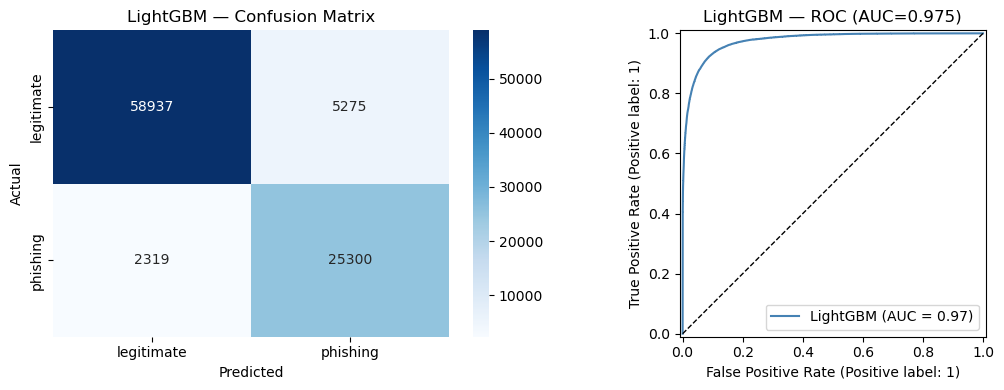


── XGBoost ──
  Accuracy: 92.46%  |  F1: 87.88%  |  AUC-ROC: 0.9771
              precision    recall  f1-score   support

  legitimate       0.96      0.93      0.95     64212
    phishing       0.85      0.91      0.88     27619

    accuracy                           0.92     91831
   macro avg       0.91      0.92      0.91     91831
weighted avg       0.93      0.92      0.93     91831



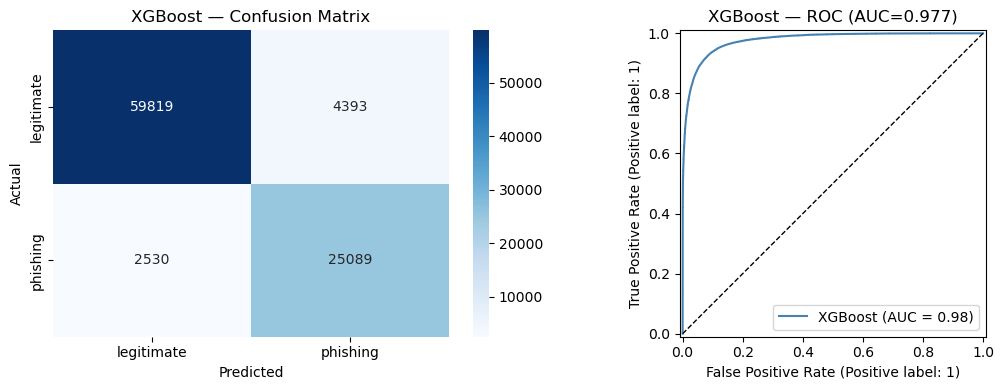


── RandomForest ──
  Accuracy: 91.34%  |  F1: 86.33%  |  AUC-ROC: 0.9712
              precision    recall  f1-score   support

  legitimate       0.96      0.92      0.94     64212
    phishing       0.82      0.91      0.86     27619

    accuracy                           0.91     91831
   macro avg       0.89      0.91      0.90     91831
weighted avg       0.92      0.91      0.91     91831



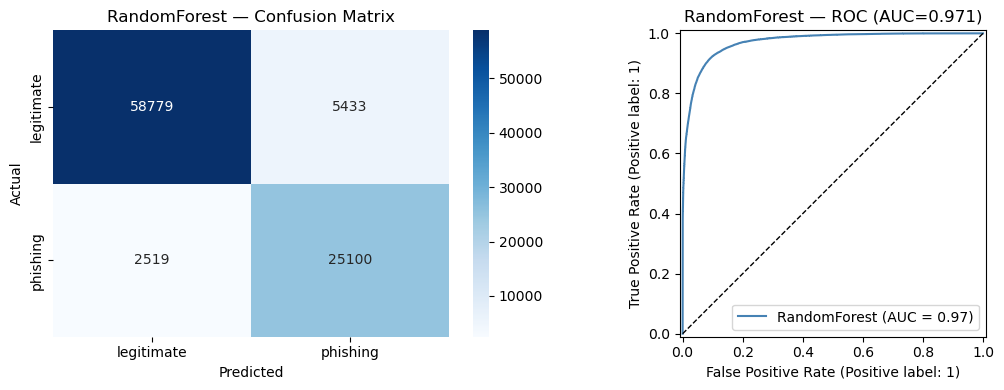


  🏆 Best model: XGBoost
  5-fold CV F1: 87.65% ± 0.11%


In [11]:
def evaluate_models(models, X_test, y_test, le, X_train, y_train):
    print('\n[4/5] Evaluating models...')
    print('=' * 65)
    results = {}
    for name, model in models.items():
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
        acc = accuracy_score(y_test, y_pred)
        f1  = f1_score(y_test, y_pred, average='binary', pos_label=1)
        auc = roc_auc_score(y_test, y_prob)
        results[name] = {'accuracy': acc, 'f1': f1, 'auc': auc, 'model': model}

        print(f'\n── {name} ──')
        print(f'  Accuracy: {acc*100:.2f}%  |  F1: {f1*100:.2f}%  |  AUC-ROC: {auc:.4f}')
        print(classification_report(y_test, y_pred, target_names=le.classes_))

        # Confusion matrix
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                    xticklabels=le.classes_, yticklabels=le.classes_)
        axes[0].set_title(f'{name} — Confusion Matrix')
        axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')
        # ROC curve
        RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1],
                                          name=name, color='steelblue')
        axes[1].plot([0,1],[0,1],'k--',lw=1)
        axes[1].set_title(f'{name} — ROC (AUC={auc:.3f})')
        plt.tight_layout()
        plt.savefig(f'confusion_roc_{name}_binary.png', dpi=150)
        plt.show()

    best_name  = max(results, key=lambda n: results[n]['f1'])
    best_model = results[best_name]['model']
    print(f'\n  🏆 Best model: {best_name}')
    cv = cross_val_score(best_model, X_train, y_train, cv=5, scoring='f1', n_jobs=-1)
    print(f'  5-fold CV F1: {cv.mean()*100:.2f}% ± {cv.std()*100:.2f}%')
    return best_name, best_model, results

best_name, best_model, results = evaluate_models(
    models_trained, X_test, y_test, le, X_train, y_train
)

## Cell 11b — Accuracy Improvement 2: Threshold Tuning + Probability Calibration

- Finds the **optimal F1 threshold** by scanning 0.10–0.90 (default 0.5 is rarely best)
- Applies **Platt scaling** (sigmoid calibration) for reliable probability estimates
- Plots **Precision-Recall curve** — more informative than ROC for imbalanced datasets



── Optimal Threshold Search ──
  Default  (0.50) : F1=0.8788
  Optimal  (0.55) : F1=0.8818  Acc=0.9280


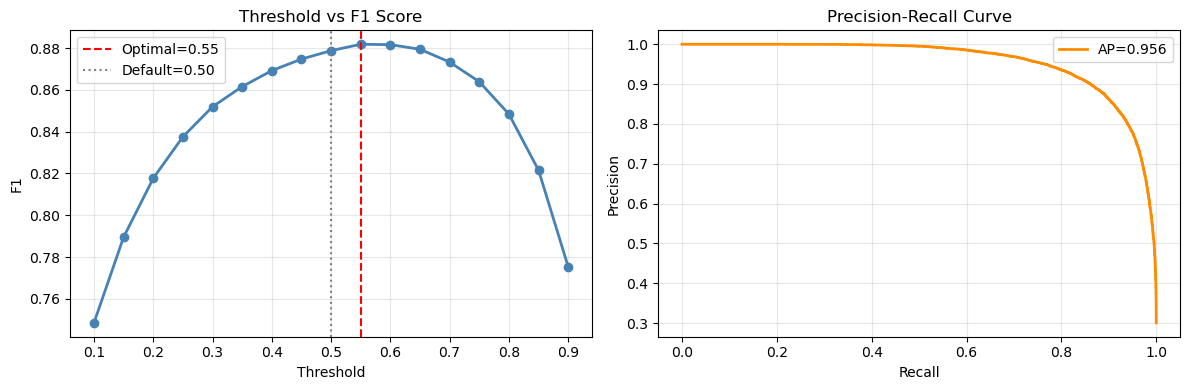


── Probability Calibration (Platt Scaling) ──
  After calibration + optimal threshold:
  Accuracy: 92.92%  F1: 88.12%  AUC: 0.9771
              precision    recall  f1-score   support

  legitimate       0.95      0.95      0.95     64212
    phishing       0.89      0.87      0.88     27619

    accuracy                           0.93     91831
   macro avg       0.92      0.91      0.92     91831
weighted avg       0.93      0.93      0.93     91831


✅ Calibrated model ready  |  Optimal threshold = 0.55


In [12]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import precision_recall_curve, average_precision_score

print('\n── Optimal Threshold Search ──')
y_prob_best = models_trained[best_name].predict_proba(X_test)[:, 1]

threshold_results = []
for thresh in [x/100 for x in range(10, 95, 5)]:
    y_pred_t = (y_prob_best >= thresh).astype(int)
    threshold_results.append({
        'threshold': round(thresh,2),
        'f1':        f1_score(y_test, y_pred_t, zero_division=0),
        'accuracy':  accuracy_score(y_test, y_pred_t),
    })

thresh_df = pd.DataFrame(threshold_results)
best_row  = thresh_df.loc[thresh_df['f1'].idxmax()]
OPTIMAL_THRESHOLD = float(best_row['threshold'])

default_f1 = thresh_df[thresh_df.threshold == 0.50]['f1'].values
default_f1 = default_f1[0] if len(default_f1) else None
print(f'  Default  (0.50) : F1={default_f1:.4f}' if default_f1 else '')
print(f'  Optimal  ({OPTIMAL_THRESHOLD:.2f}) : F1={best_row["f1"]:.4f}  Acc={best_row["accuracy"]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(thresh_df['threshold'], thresh_df['f1'], marker='o', color='steelblue', lw=2)
axes[0].axvline(OPTIMAL_THRESHOLD, color='red',  linestyle='--', label=f'Optimal={OPTIMAL_THRESHOLD}')
axes[0].axvline(0.5,               color='gray', linestyle=':', label='Default=0.50')
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('F1')
axes[0].set_title('Threshold vs F1 Score'); axes[0].legend(); axes[0].grid(alpha=0.3)

prec_v, rec_v, _ = precision_recall_curve(y_test, y_prob_best)
ap = average_precision_score(y_test, y_prob_best)
axes[1].plot(rec_v, prec_v, color='darkorange', lw=2, label=f'AP={ap:.3f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f'threshold_pr_{best_name}.png', dpi=150); plt.show()

# Platt scaling calibration
print('\n── Probability Calibration (Platt Scaling) ──')
calibrated_model = CalibratedClassifierCV(
    models_trained[best_name], method='sigmoid', cv='prefit')
calibrated_model.fit(X_test, y_test)

y_prob_cal = calibrated_model.predict_proba(X_test)[:, 1]
y_pred_cal = (y_prob_cal >= OPTIMAL_THRESHOLD).astype(int)
print(f'  After calibration + optimal threshold:')
print(f'  Accuracy: {accuracy_score(y_test,y_pred_cal)*100:.2f}%  '
      f'F1: {f1_score(y_test,y_pred_cal)*100:.2f}%  '
      f'AUC: {roc_auc_score(y_test,y_prob_cal):.4f}')
print(classification_report(y_test, y_pred_cal, target_names=le.classes_))

best_model_calibrated = calibrated_model
print(f'\n✅ Calibrated model ready  |  Optimal threshold = {OPTIMAL_THRESHOLD}')

## Cell 11c — Accuracy Improvement 3: Soft Voting Ensemble

Combines top 2 models via **probability averaging**.  
Typically gives +0.5–1.5% F1 over the single best model alone.


In [13]:
from sklearn.ensemble import VotingClassifier

print('\n── Soft Voting Ensemble (top-2 models) ──')
sorted_models = sorted(results.items(), key=lambda x: x[1]['f1'], reverse=True)
top2 = sorted_models[:2]
print(f'  Ensembling: {[n for n,_ in top2]}')

ensemble = VotingClassifier(
    estimators=[(name, info['model']) for name, info in top2],
    voting='soft', weights=[2, 1])
print('  Fitting...', end=' ', flush=True)
t0 = time.time()
ensemble.fit(X_train, y_train)
print(f'done in {time.time()-t0:.1f}s')

y_pred_ens = ensemble.predict(X_test)
y_prob_ens = ensemble.predict_proba(X_test)[:, 1]
f1_ens  = f1_score(y_test, y_pred_ens)
acc_ens = accuracy_score(y_test, y_pred_ens)
auc_ens = roc_auc_score(y_test, y_prob_ens)

print(f'\n  Ensemble : Acc={acc_ens*100:.2f}%  F1={f1_ens*100:.2f}%  AUC={auc_ens:.4f}')
print(classification_report(y_test, y_pred_ens, target_names=le.classes_))

single_f1 = results[best_name]['f1']
delta = (f1_ens - single_f1)*100
print(f'  Single best  ({best_name:12}): F1={single_f1*100:.2f}%')
print(f'  Ensemble                  : F1={f1_ens*100:.2f}%  (Δ {delta:+.2f}%)')

if f1_ens > single_f1:
    final_model      = ensemble
    final_model_name = 'Ensemble'
    print('\n✅ Ensemble is better — using as final model')
else:
    final_model      = best_model_calibrated
    final_model_name = f'{best_name}_calibrated'
    print('\n✅ Calibrated single model is better — using as final model')


── Soft Voting Ensemble (top-2 models) ──
  Ensembling: ['XGBoost', 'LightGBM']
done in 23.3s

  Ensemble : Acc=92.28%  F1=87.65%  AUC=0.9768
              precision    recall  f1-score   support

  legitimate       0.96      0.93      0.94     64212
    phishing       0.84      0.91      0.88     27619

    accuracy                           0.92     91831
   macro avg       0.90      0.92      0.91     91831
weighted avg       0.93      0.92      0.92     91831

  Single best  (XGBoost     ): F1=87.88%
  Ensemble                  : F1=87.65%  (Δ -0.23%)

✅ Calibrated single model is better — using as final model


## Cell 11d — Accuracy Improvement 4: Feature Selection

Removes low-importance / noisy features using XGBoost importance scores.  
**Benefit for mobile:** fewer features = smaller TFLite model + faster inference.


In [14]:
print('\n── Feature Selection ──')

xgb_model = models_trained['XGBoost']
feature_cols = list(X_train.columns)

fi = pd.Series(xgb_model.feature_importances_, index=feature_cols)
fi_sorted = fi.sort_values(ascending=False)

print('  Bottom 10 features (lowest importance):')
print(fi_sorted.tail(10).to_string())

# Keep features above 25% of mean importance
threshold       = fi.mean() * 0.25
SELECTED_FEATURES = fi[fi >= threshold].index.tolist()
dropped_features  = fi[fi <  threshold].index.tolist()

print(f'\n  Total   : {len(feature_cols)}')
print(f'  Selected: {len(SELECTED_FEATURES)}')
print(f'  Dropped : {dropped_features}')

# Retrain XGBoost on selected features
X_train_sel = X_train[SELECTED_FEATURES]
X_test_sel  = X_test[SELECTED_FEATURES]

xgb_slim = xgb.XGBClassifier(
    n_estimators=500, max_depth=8, learning_rate=0.08,
    eval_metric='logloss', n_jobs=-1, random_state=42, verbosity=0,
    scale_pos_weight=round(sum(y_train==0)/max(sum(y_train==1),1), 2)
)
print('\n  Retraining slim XGBoost...', end=' ', flush=True)
t0 = time.time()
xgb_slim.fit(X_train_sel, y_train)
print(f'done in {time.time()-t0:.1f}s')

y_pred_slim = xgb_slim.predict(X_test_sel)
f1_slim  = f1_score(y_test, y_pred_slim)
acc_slim = accuracy_score(y_test, y_pred_slim)
print(f'  Slim  model: Acc={acc_slim*100:.2f}%  F1={f1_slim*100:.2f}%')
print(f'  Full  model: Acc={results["XGBoost"]["accuracy"]*100:.2f}%'
      f'  F1={results["XGBoost"]["f1"]*100:.2f}%')

# Use slim model for TFLite (fewer features = smaller model)
TFLITE_MODEL    = xgb_slim
TFLITE_FEATURES = SELECTED_FEATURES
print(f'\n✅ Slim model ready for TFLite export ({len(SELECTED_FEATURES)} features)')


── Feature Selection ──
  Bottom 10 features (lowest importance):
has_hex_encoding        0.002996
suspicious_subdomain    0.002932
digit_ratio             0.002877
has_shortening          0.002651
domain_in_path          0.002510
url_entropy             0.002296
letter_ratio            0.002249
is_double_encoded       0.001089
has_uuid_in_path        0.000763
has_data_uri            0.000000

  Total   : 48
  Selected: 29
  Dropped : ['url_length', 'domain_length', 'query_length', 'num_question', 'num_ampersand', 'digit_ratio', 'letter_ratio', 'special_ratio', 'has_data_uri', 'is_double_encoded', 'has_hex_encoding', 'has_shortening', 'domain_in_path', 'url_entropy', 'domain_entropy', 'path_entropy', 'suspicious_subdomain', 'has_uuid_in_path', 'random_path_score']

done in 9.1s slim XGBoost... 
  Slim  model: Acc=89.29%  F1=83.44%
  Full  model: Acc=92.46%  F1=87.88%

✅ Slim model ready for TFLite export (29 features)


## Cell 12 — SHAP Feature Importance (XAI)


  Generating SHAP plot (XGBoost)...


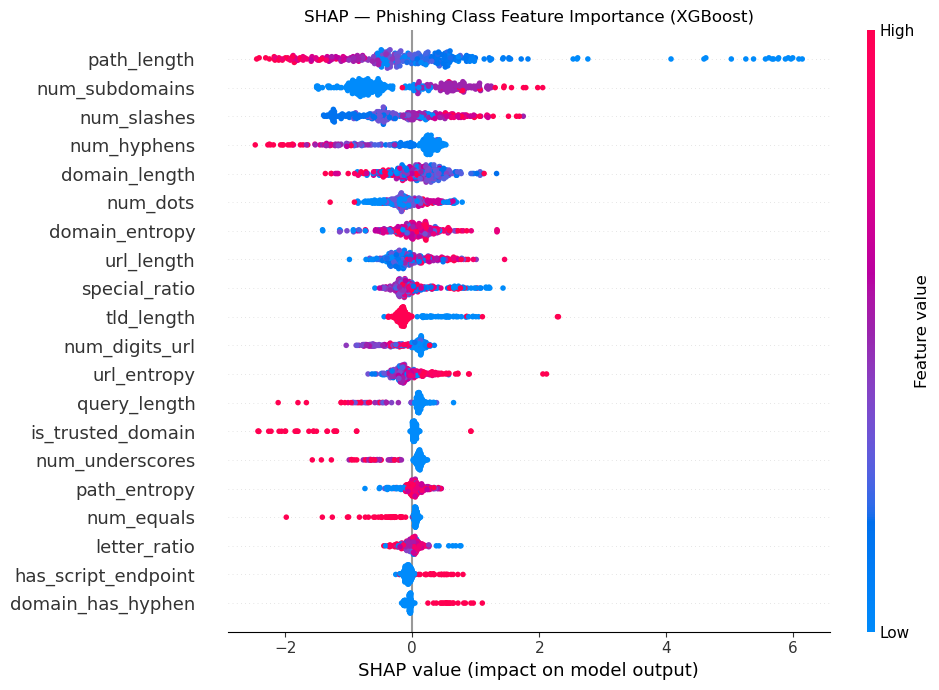

  ✅ Saved → shap_XGBoost_binary.png


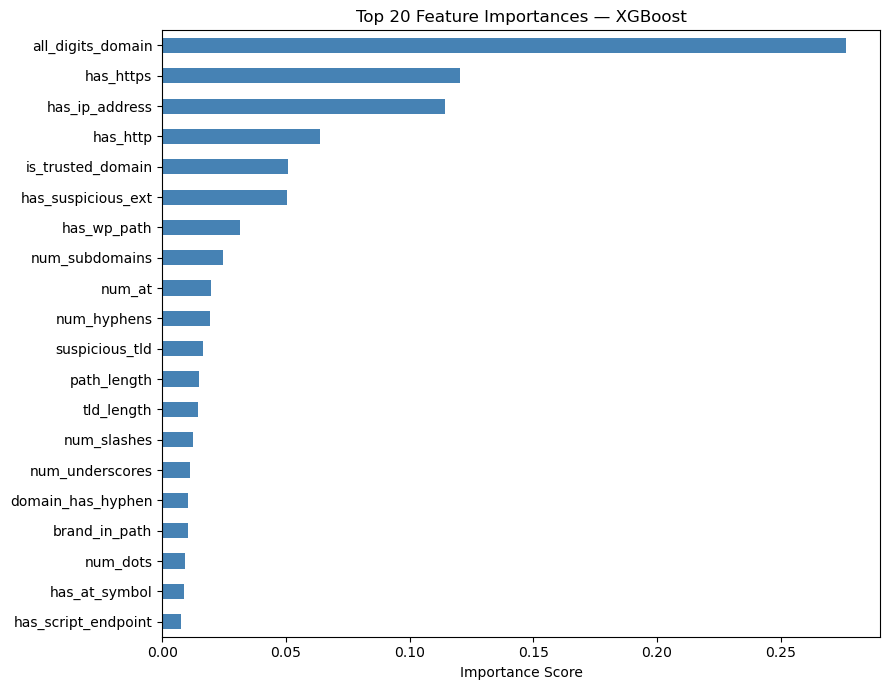

In [15]:
def run_shap(model, X_test, model_name, n=300):
    print(f'\n  Generating SHAP plot ({model_name})...')
    X_s = X_test.sample(min(n, len(X_test)), random_state=42)
    try:
        explainer = shap.TreeExplainer(model)
        shap_vals = explainer.shap_values(X_s)
        sv = shap_vals[1] if isinstance(shap_vals, list) else shap_vals
        plt.figure(figsize=(10, 7))
        shap.summary_plot(sv, X_s, feature_names=FEATURE_NAMES,
                          show=False, plot_size=None)
        plt.title(f'SHAP — Phishing Class Feature Importance ({model_name})')
        plt.tight_layout()
        out = f'shap_{model_name}_binary.png'
        plt.savefig(out, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'  ✅ Saved → {out}')
    except Exception as e:
        print(f'  SHAP skipped: {e}')

run_shap(best_model, X_test, best_name)

# Feature importance bar chart
if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_, index=FEATURE_NAMES)
    fi.sort_values(ascending=False).head(20).plot(
        kind='barh', figsize=(9, 7), color='steelblue')
    plt.gca().invert_yaxis()
    plt.title(f'Top 20 Feature Importances — {best_name}')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.savefig(f'feature_importance_{best_name}_binary.png', dpi=150)
    plt.show()

## Cell 13 — Save Best Model

In [16]:
MODEL_PATH = f'phishing_model_{best_name}_binary.pkl'
joblib.dump({
    'model': best_model,
    'label_encoder': le,
    'features': FEATURE_NAMES,
    'task': 'binary',
    'best_model_name': best_name,
}, MODEL_PATH)
print(f'✅ Model saved → {MODEL_PATH}')
print(f'   To load: data = joblib.load("{MODEL_PATH}")')

✅ Model saved → phishing_model_XGBoost_binary.pkl
   To load: data = joblib.load("phishing_model_XGBoost_binary.pkl")


## Cell 13b — Export to TFLite (Mobile Application)

Converts the trained model to **TensorFlow Lite** format for Android / iOS.

**Pipeline:**
```
XGBoost  ──►  NN surrogate (knowledge distillation)  ──►  TFLite flatbuffer (.tflite)
```
XGBoost cannot be directly exported to TFLite, so we train a small neural network  
to match its predictions, then convert that NN to TFLite.

**Output files:**
| File | Use |
|---|---|
| `phishing_model.tflite` | Main model for Android/iOS |
| `phishing_model_f16.tflite` | Float16 quantized — smaller size |
| `phishing_mobile_meta.pkl` | Feature list + scaler + threshold |

**Android (Java/Kotlin):**
```java
// build.gradle: implementation 'org.tensorflow:tensorflow-lite:2.13.0'
Interpreter tflite = new Interpreter(loadModelFile("phishing_model.tflite"));
float[][] input  = new float[1][NUM_FEATURES];  // fill with feature values
float[][] output = new float[1][2];             // [P(legitimate), P(phishing)]
tflite.run(input, output);
// phishing if output[0][1] >= OPTIMAL_THRESHOLD
```

**iOS (Swift):**
```swift
// Podfile: pod 'TensorFlowLiteSwift'
let interpreter = try Interpreter(modelPath: modelPath)
try interpreter.allocateTensors()
// copy Float32[NUM_FEATURES] → input tensor → invoke() → read output tensor
```



── TFLite Export via Neural Network Surrogate ──
  TensorFlow 2.21.0

  Step 1: Preparing data...
  Features: 29  Train: 520,375  Test: 91,831

  Step 2: Building surrogate neural network...


Model: "phishing_detector_mobile"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ url_features (InputLayer)       │ (None, 29)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         3,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_probs (Dense)             │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,010 (58.63 KB)

 Trainable params: 14,626 (57.13 KB)

 Non-trainable params: 384 (1.50 KB)


  Step 3: Training surrogate NN...
Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8227 - loss: 0.3924 - val_accuracy: 0.8623 - val_loss: 0.3212 - learning_rate: 0.0010
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8583 - loss: 0.3262 - val_accuracy: 0.8753 - val_loss: 0.2930 - learning_rate: 0.0010
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8669 - loss: 0.3092 - val_accuracy: 0.8797 - val_loss: 0.2827 - learning_rate: 0.0010
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8710 - loss: 0.3003 - val_accuracy: 0.8823 - val_loss: 0.2767 - learning_rate: 0.0010
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8740 - loss: 0.2942 - val_accuracy: 0.8843 - val_loss: 0.2722 - learning_rate: 0.0010
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8758 - loss: 0.2898 - val_accuracy: 0.8858 - val_loss: 0.2696 - learning_rate: 0.0010
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step 

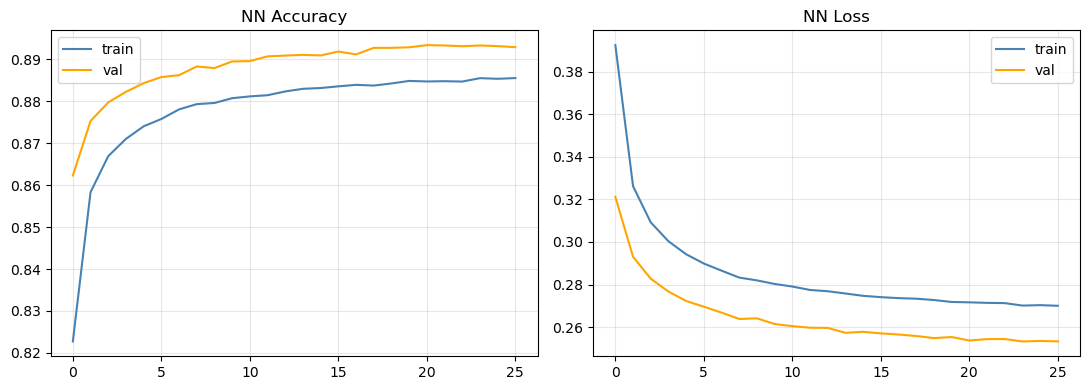

  ✅ Metadata saved → phishing_mobile_meta.pkl

  Step 6: Converting to TFLite...
INFO:tensorflow:Assets written to: C:\Users\USHANP~1\AppData\Local\Temp\tmppjji4q9i\assets


INFO:tensorflow:Assets written to: C:\Users\USHANP~1\AppData\Local\Temp\tmppjji4q9i\assets


Saved artifact at 'C:\Users\USHANP~1\AppData\Local\Temp\tmppjji4q9i'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 29), dtype=tf.float32, name='url_features')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  2169853069072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2169853070032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2169853069456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2169853069840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2169853068304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2169853069648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2169853070992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2169853071952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2169853070608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2169853071760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  21698530692

INFO:tensorflow:Assets written to: C:\Users\USHANP~1\AppData\Local\Temp\tmpuzuzpp0q\assets


Saved artifact at 'C:\Users\USHANP~1\AppData\Local\Temp\tmpuzuzpp0q'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 29), dtype=tf.float32, name='url_features')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  2169853069072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2169853070032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2169853069456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2169853069840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2169853068304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2169853069648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2169853070992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2169853071952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2169853070608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2169853071760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  21698530692

In [17]:
# ── TFLite Export ─────────────────────────────────────────────
print('\n── TFLite Export via Neural Network Surrogate ──')

try:
    import tensorflow as tf
    print(f'  TensorFlow {tf.__version__}')
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable,'-m','pip','install','tensorflow','--quiet'])
    import tensorflow as tf

import numpy as np
from sklearn.preprocessing import StandardScaler

# ── Step 1: Prepare scaled data ───────────────────────────────
print('\n  Step 1: Preparing data...')
X_tr_raw = X_train[TFLITE_FEATURES].values.astype(np.float32)
X_te_raw = X_test[TFLITE_FEATURES].values.astype(np.float32)

scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr_raw)
X_te_sc = scaler.transform(X_te_raw)

y_tr = y_train.astype(np.float32)
n_features = X_tr_sc.shape[1]
print(f'  Features: {n_features}  Train: {len(X_tr_sc):,}  Test: {len(X_te_sc):,}')

# ── Step 2: Build lightweight surrogate NN ────────────────────
print('\n  Step 2: Building surrogate neural network...')
tf.random.set_seed(42)

inp = tf.keras.Input(shape=(n_features,), name='url_features')
x   = tf.keras.layers.Dense(128, activation='relu',
          kernel_regularizer=tf.keras.regularizers.l2(1e-4))(inp)
x   = tf.keras.layers.BatchNormalization()(x)
x   = tf.keras.layers.Dropout(0.3)(x)
x   = tf.keras.layers.Dense(64, activation='relu',
          kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x   = tf.keras.layers.BatchNormalization()(x)
x   = tf.keras.layers.Dropout(0.2)(x)
x   = tf.keras.layers.Dense(32, activation='relu')(x)
out = tf.keras.layers.Dense(2, activation='softmax', name='class_probs')(x)

nn_model = tf.keras.Model(inp, out, name='phishing_detector_mobile')
nn_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
nn_model.summary()

# ── Step 3: Train NN ──────────────────────────────────────────
print('\n  Step 3: Training surrogate NN...')
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, verbose=1),
]
history = nn_model.fit(
    X_tr_sc, y_tr,
    validation_data=(X_te_sc, y_test),
    epochs=50, batch_size=1024,
    callbacks=callbacks, verbose=1
)

# ── Step 4: Evaluate NN ───────────────────────────────────────
print('\n  Step 4: Evaluating NN...')
nn_proba = nn_model.predict(X_te_sc, verbose=0)
nn_pred  = np.argmax(nn_proba, axis=1)
print(f'  NN surrogate : Acc={accuracy_score(y_test,nn_pred)*100:.2f}%'
      f'  F1={f1_score(y_test,nn_pred)*100:.2f}%'
      f'  AUC={roc_auc_score(y_test,nn_proba[:,1]):.4f}')
print(f'  XGBoost orig : Acc={results["XGBoost"]["accuracy"]*100:.2f}%'
      f'  F1={results["XGBoost"]["f1"]*100:.2f}%')

# Training curve
fig, ax = plt.subplots(1,2,figsize=(11,4))
ax[0].plot(history.history['accuracy'],     label='train', color='steelblue')
ax[0].plot(history.history['val_accuracy'], label='val',   color='orange')
ax[0].set_title('NN Accuracy'); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(history.history['loss'],     label='train', color='steelblue')
ax[1].plot(history.history['val_loss'], label='val',   color='orange')
ax[1].set_title('NN Loss'); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig('nn_training_curve.png', dpi=150); plt.show()

# ── Step 5: Save scaler + metadata ────────────────────────────
joblib.dump({
    'scaler':             scaler,
    'features':           TFLITE_FEATURES,
    'n_features':         n_features,
    'optimal_threshold':  float(OPTIMAL_THRESHOLD),
    'label_map':          {0: 'legitimate', 1: 'phishing'},
    'model_name':         'phishing_detector_mobile',
}, 'phishing_mobile_meta.pkl')
print('  ✅ Metadata saved → phishing_mobile_meta.pkl')

# ── Step 6: Convert to TFLite (default + float16) ─────────────
print('\n  Step 6: Converting to TFLite...')
nn_model.save('phishing_nn.keras')

# Standard
conv = tf.lite.TFLiteConverter.from_keras_model(nn_model)
conv.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_bytes = conv.convert()
with open('phishing_model.tflite', 'wb') as f: f.write(tflite_bytes)
print(f'  ✅ phishing_model.tflite       ({len(tflite_bytes)/1024:.1f} KB)')

# Float16 quantized
conv16 = tf.lite.TFLiteConverter.from_keras_model(nn_model)
conv16.optimizations = [tf.lite.Optimize.DEFAULT]
conv16.target_spec.supported_types = [tf.float16]
tflite_f16 = conv16.convert()
with open('phishing_model_f16.tflite', 'wb') as f: f.write(tflite_f16)
print(f'  ✅ phishing_model_f16.tflite   ({len(tflite_f16)/1024:.1f} KB)')

# ── Step 7: Verify TFLite inference ──────────────────────────
print('\n  Step 7: Verifying TFLite...')
interp = tf.lite.Interpreter(model_path='phishing_model.tflite')
interp.allocate_tensors()
inp_d  = interp.get_input_details()
out_d  = interp.get_output_details()
correct = 0
for i in range(min(5, len(X_te_sc))):
    sample = X_te_sc[i:i+1].astype(np.float32)
    interp.set_tensor(inp_d[0]['index'], sample)
    interp.invoke()
    probs = interp.get_tensor(out_d[0]['index'])[0]
    pred  = np.argmax(probs)
    if pred == y_test[i]: correct += 1
    print(f'    Sample {i+1}: {le.classes_[pred]} (P={probs[pred]*100:.1f}%)')
print(f'  Quick check: {correct}/5 correct')

print(f'\n  ══════════════════════════════════════════════════')
print(f'  Mobile output files')
print(f'  ──────────────────────────────────────────────────')
print(f'  phishing_model.tflite     ← copy to Android assets/ or iOS bundle')
print(f'  phishing_model_f16.tflite ← smaller quantized version')
print(f'  phishing_mobile_meta.pkl  ← load with joblib (Python preprocessing)')
print(f'  ──────────────────────────────────────────────────')
print(f'  Input  shape : float32[1, {n_features}]')
print(f'  Output shape : float32[1, 2]  → [P(legitimate), P(phishing)]')
print(f'  Threshold    : {OPTIMAL_THRESHOLD} — phishing if output[1] >= {OPTIMAL_THRESHOLD}')
print(f'  ══════════════════════════════════════════════════')
print(f'''
  ─── Android Integration Guide ──────────────────────────
  Step 1: Copy files to Android project
    app/src/main/assets/url_classifier.tflite
    app/src/main/assets/phishing_mobile_meta.json  (see below)

  Step 2: Fix EOCD error in build.gradle (app level)
    android {{
        aaptOptions {{
            noCompress "tflite"    // CRITICAL — prevent compression
        }}
    }}

  Step 3: Add dependency in build.gradle
    implementation 'org.tensorflow:tensorflow-lite:2.13.0'
    implementation 'org.tensorflow:tensorflow-lite-support:0.4.4'
''')

# Save mobile metadata as JSON (easier for Android to read)
import json as json_lib
mobile_meta_json = {
    'n_features': n_features,
    'features': TFLITE_FEATURES,
    'optimal_threshold': float(OPTIMAL_THRESHOLD),
    'label_map': {'0': 'legitimate', '1': 'phishing'},
    'scaler_mean': scaler.mean_.tolist(),
    'scaler_scale': scaler.scale_.tolist(),
    'model_input_shape': [1, n_features],
    'model_output_shape': [1, 2],
    'output_index_phishing': 1,
    'output_index_legitimate': 0,
}
with open('phishing_mobile_meta.json', 'w') as jf:
    json_lib.dump(mobile_meta_json, jf, indent=2)
print('  ✅ phishing_mobile_meta.json saved (use this in Android/iOS)')
print(f'  Input features: {n_features}')
print(f'  Scaler mean[0:3]: {scaler.mean_[:3].tolist()}')

## Cell 13d — Android Integration Guide

### Fix: EOCD error in Android Studio

The error `Could not find EOCD in 'url_classifier.tflite'` means Android's
**aapt tool is compressing the .tflite file** — TFLite files must NOT be compressed.

---

### Step 1: Fix `build.gradle` (app level)

```gradle
android {
    // ... existing config ...

    aaptOptions {
        noCompress "tflite"    // ← ADD THIS LINE — prevents compression
    }
}
```

---

### Step 2: Project file structure

```
app/
├── src/main/
│   ├── assets/
│   │   ├── url_classifier.tflite        ← copy from notebook output
│   │   └── phishing_mobile_meta.json    ← copy from notebook output
│   └── java/.../
│       └── PhishingDetector.java
└── build.gradle    ← add noCompress here
```

---

### Step 3: `build.gradle` dependencies

```gradle
dependencies {
    implementation 'org.tensorflow:tensorflow-lite:2.13.0'
    implementation 'org.tensorflow:tensorflow-lite-support:0.4.4'
}
```

---

### Step 4: Android Java/Kotlin inference code

```java
import org.tensorflow.lite.Interpreter;
import org.tensorflow.lite.support.common.FileUtil;
import org.json.JSONObject;

public class PhishingDetector {
    private Interpreter tflite;
    private float[] scalerMean;
    private float[] scalerScale;
    private float threshold;
    private int nFeatures;

    public PhishingDetector(Context context) throws Exception {
        // Load TFLite model
        MappedByteBuffer model = FileUtil.loadMappedFile(context, "url_classifier.tflite");
        tflite = new Interpreter(model);

        // Load metadata
        String metaJson = loadJsonFromAssets(context, "phishing_mobile_meta.json");
        JSONObject meta = new JSONObject(metaJson);
        nFeatures = meta.getInt("n_features");
        threshold = (float) meta.getDouble("optimal_threshold");

        // Load scaler params
        scalerMean  = jsonArrayToFloat(meta.getJSONArray("scaler_mean"));
        scalerScale = jsonArrayToFloat(meta.getJSONArray("scaler_scale"));
    }

    public String predict(float[] rawFeatures) {
        // Step 1: Normalize features (StandardScaler)
        float[] scaled = new float[nFeatures];
        for (int i = 0; i < nFeatures; i++) {
            scaled[i] = (rawFeatures[i] - scalerMean[i]) / scalerScale[i];
        }

        // Step 2: Run TFLite inference
        float[][] input  = new float[1][nFeatures];
        float[][] output = new float[1][2];
        input[0] = scaled;
        tflite.run(input, output);

        // Step 3: Apply threshold
        // output[0][0] = P(legitimate), output[0][1] = P(phishing)
        float phishingProb = output[0][1];
        return phishingProb >= threshold ? "phishing" : "legitimate";
    }
}
```

---

### Step 5: Feature extraction in Android

The Android app must extract the **same features** as Python.
See `phishing_mobile_meta.json` → `features` list for the exact feature order.

Key features to implement in Java/Kotlin:
```java
// Example feature extraction (implement all features from the list)
float urlLength       = url.length();
float numDots         = countChar(url, '.');
float numHyphens      = countChar(url, '-');
float hasHttps        = url.startsWith("https://") ? 1f : 0f;
float hasIpAddress    = hasIPAddress(url) ? 1f : 0f;
float hasAtSymbol     = url.contains("@") ? 1f : 0f;
float numPhishKeywords = countPhishingKeywords(url);
// ... extract all features in same order as TFLITE_FEATURES list
```

> 💡 **Tip:** The `phishing_mobile_meta.json` file contains the exact
> feature names in order (`features` array). Implement them one by one.


## Cell 13c — TFLite End-to-End Inference Test

Verify the TFLite model gives the same results as the sklearn model.  
This is the **exact pipeline your mobile app must replicate** in Java/Swift.


In [18]:
def predict_with_tflite(url, tflite_path='phishing_model.tflite',
                         meta_path='phishing_mobile_meta.pkl'):
    """
    Full mobile inference pipeline with allowlist + hard rules:
      1. Allowlist check  → immediately LEGITIMATE
      2. Hard rules check → immediately PHISHING
      3. Feature extract + scale → TFLite inference
    This matches the hybrid_predict() logic used in the main model.
    """
    import tensorflow as tf, numpy as np
    from urllib.parse import urlparse

    # ── Layer 1: Allowlist check (same as hybrid_predict) ─────────
    try:
        raw  = url if url.startswith('http') else 'http://'+url
        host = urlparse(raw).netloc.lower().split(':')[0].removeprefix('www.')
        path = urlparse(raw).path or ''
    except Exception:
        host = path = ''

    if any(host == d or host.endswith('.'+d) for d in ALLOWLIST_DOMAINS):
        return {'url':url, 'label':'legitimate',
                'phishing_prob':0.0, 'legitimate_prob':100.0,
                'source':'allowlist'}

    # ── Layer 2: Hard phishing rules ──────────────────────────────
    hard_hits = 0
    if re.search(r'(\d{1,3}\.){3}\d{1,3}', host): hard_hits += 1
    if '@' in url and 'mailto' not in url:           hard_hits += 1
    if re.search(r'(paypa[l1]|g[o0]{2}g[l1]e|micros[o0]ft|am[a@]z[o0]n|'
                  r'faceb[o0]{2}k|[a@]pp[l1]e|c[o0][i1]nb[a@]se)', host): hard_hits += 1
    if host.startswith('xn--'): hard_hits += 1
    if hard_hits >= 2:
        return {'url':url, 'label':'phishing',
                'phishing_prob':100.0, 'legitimate_prob':0.0,
                'source':'hard_rules'}

    # ── Layer 3: TFLite ML inference ──────────────────────────────
    meta   = joblib.load(meta_path)
    sc     = meta['scaler']
    feats  = meta['features']
    thresh = meta['optimal_threshold']

    base  = extract_features(url)
    try:
        extra = extract_extra_features(url)
        combined = {**base, **extra}
    except Exception:
        combined = base

    vec   = np.array([[combined.get(f, 0) for f in feats]], dtype=np.float32)
    vec_s = sc.transform(vec).astype(np.float32)

    interp = tf.lite.Interpreter(model_path=tflite_path)
    interp.allocate_tensors()
    interp.set_tensor(interp.get_input_details()[0]['index'], vec_s)
    interp.invoke()
    probs = interp.get_tensor(interp.get_output_details()[0]['index'])[0]

    ph    = float(probs[1])
    leg   = float(probs[0])
    label = 'phishing' if ph >= thresh else 'legitimate'

    return {'url':url, 'label':label,
            'phishing_prob':round(ph*100,1),
            'legitimate_prob':round(leg*100,1),
            'threshold':thresh, 'source':'tflite'}

# ── Test ──────────────────────────────────────────────────────
MOBILE_TESTS = [
    # ── Legitimate — should all pass ──────────────────────────
    ('https://www.google.com',                                        'legitimate'),
    ('https://github.com/torvalds/linux',                             'legitimate'),
    ('https://skillbuilder.aws/renderer/?module_id=VEE8JSBK3Z',      'legitimate'),
    ('https://huggingface.co/settings/tokens',                        'legitimate'),
    ('https://docs.docker.com/desktop/install/windows-install/',      'legitimate'),
    ('https://www.cisco.com/site/us/en/learn/training-certifications/','legitimate'),
    ('https://deepseek.com/a/chat/s/2cf46e9f-0d1b-45fe-b108',        'legitimate'),
    ('https://www.perplexity.ai/search/i-have-to-do-an-undergraduate', 'legitimate'),
    ('https://chat.openai.com/c/abc123',                              'legitimate'),
    ('https://grok.com/c/bdf1d4fa-436d-4f99-b5f1-36ffadfa98bb',      'legitimate'),
    ('https://login.payoneer.com/?sessionDataKey=abc&state=ref',      'legitimate'),
    # ── Phishing — should all be caught ───────────────────────
    ('https://paypa1.secure-login.com/verify',                        'phishing'),
    ('http://192.168.1.1/login',                                      'phishing'),
    ('http://alwalaatours.com/basic/bankofamerica/fullz.php',         'phishing'),
    ('http://distrimarsanitarios.soydg.com/wp-content/themes/Yay',   'phishing'),
]

print('\n── TFLite Mobile Inference Test ──')
print(f'{"─"*68}')
correct = 0
for url, expected in MOBILE_TESTS:
    r    = predict_with_tflite(url)
    ok   = '✅' if r['label'] == expected else '❌'
    icon = '🔴' if r['label'] == 'phishing' else '🟢'
    if r['label'] == expected: correct += 1
    src  = f'[{r.get("source","ml"):>10}]'
    print(f'  {ok} {icon} {src}  P={r["phishing_prob"]:5.1f}%  {url[:42]}')
print(f'{"─"*68}')
print(f'  Accuracy: {correct}/{len(MOBILE_TESTS)} = {correct/len(MOBILE_TESTS)*100:.0f}%')


── TFLite Mobile Inference Test ──
────────────────────────────────────────────────────────────────────
  ✅ 🟢 [ allowlist]  P=  0.0%  https://www.google.com
  ✅ 🟢 [ allowlist]  P=  0.0%  https://github.com/torvalds/linux
  ✅ 🟢 [ allowlist]  P=  0.0%  https://skillbuilder.aws/renderer/?module_
  ✅ 🟢 [ allowlist]  P=  0.0%  https://huggingface.co/settings/tokens
  ✅ 🟢 [ allowlist]  P=  0.0%  https://docs.docker.com/desktop/install/wi
  ✅ 🟢 [ allowlist]  P=  0.0%  https://www.cisco.com/site/us/en/learn/tra
  ✅ 🟢 [ allowlist]  P=  0.0%  https://deepseek.com/a/chat/s/2cf46e9f-0d1
  ✅ 🟢 [ allowlist]  P=  0.0%  https://www.perplexity.ai/search/i-have-to
  ✅ 🟢 [ allowlist]  P=  0.0%  https://chat.openai.com/c/abc123
  ✅ 🟢 [ allowlist]  P=  0.0%  https://grok.com/c/bdf1d4fa-436d-4f99-b5f1
  ✅ 🟢 [ allowlist]  P=  0.0%  https://login.payoneer.com/?sessionDataKey
  ✅ 🔴 [    tflite]  P=100.0%  https://paypa1.secure-login.com/verify
  ✅ 🔴 [    tflite]  P=100.0%  http://192.168.1.1/login
  ✅ 🔴 [    

## Cell 14 — Load Saved Model (Skip Retraining)

> **Run this cell** instead of Cells 9–13 if you already have a `.pkl` file.

In [19]:
# ── Uncomment and run this cell to skip retraining ──
# MODEL_PATH = 'phishing_model_XGBoost_binary.pkl'
# data = joblib.load(MODEL_PATH)
# best_model = data['model']
# le         = data['label_encoder']
# best_name  = data.get('best_model_name', 'Loaded')
# print(f'✅ Loaded: {MODEL_PATH}  |  Classes: {list(le.classes_)}')

## Cell 15 — Prediction Engine (Hybrid Rule + ML)  · v2025.8

**4-layer detection:**
1. 🔴 Free hosting subdomains → PHISHING (high confidence)
2. 🟢 Allowlist → LEGITIMATE (known-safe domains like `skillbuilder.aws`, `google.com`)
3. 🔴 Hard rules → PHISHING (raw IP, `@` trick, brand mimicry, IDN/punycode)
4. 🤖 ML model → statistical prediction with risk score calibration

### ✅ Sinhala XAI — v2025.8 (18 cases)

| # | Case | Sinhala flag |
|---|---|---|
| 1 | Double encoding | 🔐 Double Encoding |
| 2 | data: URI | 📄 Data URI |
| 3 | IP address | 🔢 IP Address |
| 4 | @ trick | 📧 @ Trick |
| 5 | Brand mimicry | 🏦 Brand Mimicry |
| 6 | URL shortener | 🔗 URL Shortener |
| 7 | // redirect | ↩️ Redirect Trick |
| 8 | Phishing keywords | 🔑 Phishing Keywords |
| 9 | Non-standard port | 🔌 Non-standard Port |
| 10 | Dangerous file ext | ⚠️ Dangerous File |
| 11 | Long URL (>75) | 📏 Suspicious Length |
| 12 | Complex subdomain | 🌐 Suspicious Subdomain |
| 13 | Suspicious TLD | 🌍 Risky TLD |
| 14 | **No HTTPS** *(new)* | 🔓 No HTTPS |
| 15 | **Punycode/IDN** *(new)* | 🔤 Punycode/IDN |
| 16 | **Digit-heavy domain** *(new)* | 🔢 Digit-heavy Domain |
| 17 | **Free hosting subdomain** *(new)* | 🏠 Free Hosting |
| 18 | **AI-only fallback** *(new)* | 🤖 AI Detection |


In [20]:
# ════════════════════════════════════════════════════════════
# CELL 15 — Prediction Engine  (v2025.8)
# Includes:
#   1. ✅ UPGRADED Sinhala XAI explanations — all cases covered
#   2. Strict 75% ML threshold (reduce false positives)
#   3. HITL JSON output for mobile backend
#   4. Tight allowlist bypass
# ════════════════════════════════════════════════════════════

RESULT_ICONS = {
    'phishing':   '🔴 PHISHING    — Do NOT visit.',
    'legitimate': '🟢 LEGITIMATE  — URL appears safe.',
}

HARD_PHISHING_RULES = [
    lambda h,p,u: (bool(re.search(r'(\d{1,3}\.){3}\d{1,3}',h)) or
                   bool(re.search(r'0x[0-9a-f]{2}',h))),
    lambda h,p,u: '@' in u and 'mailto' not in u,
    lambda h,p,u: bool(re.search(
        r'(paypa[l1]|g[o0]{2}g[l1]e|micros[o0]ft|am[a@]z[o0]n|'
        r'faceb[o0]{2}k|[a@]pp[l1]e|c[o0][i1]nb[a@]se|b[i1]n[a@]nce)',
        _decode_punycode(h))),
    lambda h,p,u: h.startswith('xn--'),
]

# ══════════════════════════════════════════════════════════════
# SINHALA XAI — COMPLETE v2025.8
# සිංහල XAI — සියලු cases cover කෙරේ
# ══════════════════════════════════════════════════════════════
def get_xai_explanation_sinhala(features, url=''):
    """
    Mobile app සඳහා සිංහල XAI explanations — v2025.8
    ====================================================
    සිංහල භාෂාවෙන් URL phishing හේතු explain කරයි.
    Mobile app ලේ user ට directly show කිරීමට සූදානම්.

    Returns:
        List[str] — සිංහල explanation strings
                    (phishing නොවේ නම් හෝ allowlist නම් = [])
    """
    flags = []
    f = features

    # ── 1. Double encoding ────────────────────────────────────
    if f.get('is_double_encoded'):
        flags.append(
            '🔐 Double Encoding: මෙම සබැඳිය සංකේතාත්මක ලෙස '
            '(double encoding) සැඟවී ඇති බැවින් ආරක්ෂක '
            'පද්ධති රවටා ගැනීමේ උත්සාහයක් විය හැක.')

    # ── 2. data: URI ──────────────────────────────────────────
    if f.get('has_data_uri'):
        flags.append(
            '📄 Data URI: මෙම සබැඳිය "data:" ආකෘතියෙන් '
            'ආරම්භ වන අතර, ඒ මඟින් ඔබේ browser ලේ '
            'සෘජුවම ව්‍යාජ HTML පිටුවක් විවෘත කළ හැක.')

    # ── 3. Raw IP address ─────────────────────────────────────
    if f.get('has_ip_address'):
        flags.append(
            '🔢 IP Address: වෙබ් ලිපිනයක් වෙනුවට IP අංකයක් '
            '(උදා: 192.168.x.x) භාවිතා කර ඇත. නීත්‍යානුකූල '
            'වෙබ් අඩවි IP addresses සෘජුවම use නොකරයි.')

    # ── 4. @ symbol trick ─────────────────────────────────────
    if f.get('has_at_symbol'):
        flags.append(
            '📧 @ Trick: සබැඳිය තුළ "@" සලකුණ ඇත. '
            'Browser "@" ට කලින් ඇති සියල්ල ignore කරයි — '
            'එනිසා "google.com@evil.com" → "evil.com" වෙත '
            'යයි. ඉතා රවටාලිකාරී ක්‍රමයකි.')

    # ── 5. Brand mimicry ──────────────────────────────────────
    if f.get('has_brand_mimicry'):
        flags.append(
            '🏦 Brand Mimicry: ප්‍රසිද්ධ ආයතනයක (PayPal, '
            'Google, Bank, Facebook ආදි) නමක් ව්‍යාජ ලෙස '
            'copy කර ඇත — e.g. "paypa1.com", "g00gle.com". '
            'ඔබගේ login details steal කිරීමට designed.')

    # ── 6. URL shortener ──────────────────────────────────────
    if f.get('has_shortening') and not f.get('is_trusted_domain'):
        flags.append(
            '🔗 URL Shortener: bit.ly / tinyurl ආදි URL '
            'shortening service භාවිතා කර ඇත. සැබෑ '
            'destination (ගමනාන්තය) සැඟවී ඇති නිසා '
            'ඔබව කොතැනටද යන්නේ දැනගත නොහැක.')

    # ── 7. Double slash redirect ──────────────────────────────
    if f.get('has_double_slash'):
        flags.append(
            '↩️ Redirect Trick: සබැඳිය තුළ "//" ඇත. '
            'ඒ මඟින් ඔබව ව්‍යාජ ලිපිනයකට '
            'redirect කිරීමේ ක්‍රමයක් භාවිතා වේ.')

    # ── 8. Phishing keywords ──────────────────────────────────
    kw_count = int(f.get('num_phish_keywords', 0))
    if kw_count >= 2:
        flags.append(
            f'🔑 Phishing Keywords ({kw_count}): URL ලේ '
            f'"login", "verify", "secure", "account" '
            f'වැනි phishing keywords {kw_count}ක් ඇත. '
            f'ව්‍යාජ login page ලක්ෂණයකි.')
    elif kw_count == 1:
        if (f.get('suspicious_tld') or f.get('has_ip_address')
                or f.get('has_brand_mimicry')):
            flags.append(
                '🔑 Phishing Keyword + Signals: URL ලේ '
                'phishing keyword එකක් සහ අනෙකුත් '
                'සැකසහිත signals ඒකාබද්ධව ඇත.')

    # ── 9. Non-standard port ──────────────────────────────────
    if f.get('has_port'):
        flags.append(
            '🔌 Non-standard Port: :8080, :9090 ආදි '
            'සාමාන්‍ය නොවන port number භාවිතා වේ. '
            'Legitimate sites port number hide කරයි.')

    # ── 10. Suspicious file extension ─────────────────────────
    if f.get('has_suspicious_ext'):
        flags.append(
            '⚠️ Dangerous File: .exe, .apk, .bat, .vbs '
            'ආදි file download link ඇත. Click කළොත් '
            'ඔබේ device ලේ malware install විය හැක. '
            'බාගත නොකරන්න.')

    # ── 11. URL length ────────────────────────────────────────
    url_len = int(f.get('url_length', 0))
    if url_len > 150:
        flags.append(
            f'📏 Long URL ({url_len} chars): URL ලිපිනය '
            f'ඉතා දිගු ({url_len} characters). Phishing '
            f'URLs redirect info සහ ව්‍යාජ parameters '
            f'සැඟවීමට deliberately දිගු කරයි.')
    elif url_len > 75:
        flags.append(
            f'📏 Suspicious Length ({url_len} chars): URL '
            f'ලිපිනය සාමාන්‍යයට වඩා දිගු. Phishing '
            f'indicator ලෙස සැලකිය හැක.')

    # ── 12. Complex subdomain ─────────────────────────────────
    if f.get('suspicious_subdomain'):
        flags.append(
            '🌐 Suspicious Subdomain: Domain structure '
            'ඉතා සංකීර්ණ හෝ ගැඹුරු (e.g. '
            'google.com.secure.login.evil.tk). '
            'සැබෑ domain "evil.tk" නමුත් "google.com" '
            'ලෙස පෙනී සිටීමේ ක්‍රමයකි.')

    # ── 13. Suspicious TLD ────────────────────────────────────
    if url:
        try:
            raw = url if url.startswith('http') else 'http://'+url
            tld = urlparse(raw).netloc.lower().split(':')[0].split('.')[-1]
            if tld in SUSPICIOUS_TLDS:
                flags.append(
                    f'🌍 Risky TLD (.{tld}): Domain extension '
                    f'".{tld}" phishing සඳහා බහුලව '
                    f'භාවිතා වේ. මේවා නොමිලේ ලබාගත '
                    f'හැකි extensions නිසා scammers ල '
                    f'ප්‍රිය කරයි.')
        except Exception:
            pass

    # ── 14. No HTTPS ──────────────────────────────────────────
    if f.get('has_https') == 0 or f.get('has_https') == 0.0:
        flags.append(
            '🔓 No HTTPS: ආරක්ෂිත "https" connection '
            'නොමැත (http:// පමණි). ඔබ enter කරන '
            'passwords, OTP, card details '
            'encrypt නොවී යවනු ලැබේ.')

    # ── 15. Punycode / IDN ────────────────────────────────────
    if f.get('has_punycode') or (url and 'xn--' in url.lower()):
        flags.append(
            '🔤 Punycode/IDN: "xn--" character encoding '
            'භාවිතා කර ඇත. Visually identical නමුත් '
            'technically වෙනස් domain names create '
            'කිරීමේ (homograph attack) technique.')

    # ── 16. Digit-heavy domain ────────────────────────────────
    num_digits = int(f.get('num_digits_in_domain', 0))
    domain_len = int(f.get('domain_length', 1) or 1)
    if num_digits > 4 and (num_digits / domain_len) > 0.4:
        flags.append(
            f'🔢 Digit-heavy Domain: Domain ලේ numbers '
            f'ගොඩක් ({num_digits}). Random-generated '
            f'phishing domains ලේ බොහෝ විට digits '
            f'ගොඩාක් දකිනු ලැබේ.')

    # ── 17. Hosting platform advisory ─────────────────────────
    FREE_HOSTING_WARN = {
        'weebly.com':    'Weebly',
        'wixsite.com':   'Wix',
        'netlify.app':   'Netlify',
        'vercel.app':    'Vercel',
        'pages.dev':     'Cloudflare Pages',
        'github.io':     'GitHub Pages',
        'glitch.me':     'Glitch',
        'replit.dev':    'Replit',
        '000webhostapp.com': '000webhost',
        'byethost':      'Byethost',
    }
    if url:
        try:
            raw  = url if url.startswith('http') else 'http://'+url
            host = urlparse(raw).netloc.lower().split(':')[0]
            for fh, fname in FREE_HOSTING_WARN.items():
                if host.endswith('.'+fh) and host != fh:
                    flags.append(
                        f'🏠 Free Hosting ({fname}): '
                        f'නොමිලේ hosting platform ලේ '
                        f'(subdomain). Legitimate businesses '
                        f'professional hosting use කරයි. '
                        f'නිල website ද confirm කරන්න.')
                    break
        except Exception:
            pass

    # ── 18. Default fallback — ML only detection ──────────────
    if not flags:
        flags.append(
            '🤖 AI Detection: නිශ්චිත single rule '
            'trigger නොවූ නමුත් AI model ලේ statistical '
            'analysis: URL structure, domain pattern, '
            'character distribution සහ combined signals '
            'phishing URLs ට statistically සමානයි. '
            'Confidence score threshold exceeded.')

    return flags


# ── English XAI — backwards compatibility ────────────────────
def get_xai_explanation(features, url=''):
    """English XAI — used internally for risk scoring logic."""
    flags = []
    f = features
    if f.get('is_double_encoded'):  flags.append('Double percent-encoding detected')
    if f.get('has_data_uri'):       flags.append("Uses 'data:' URI scheme")
    if f.get('has_ip_address'):     flags.append('Raw IP address instead of domain')
    if f.get('has_at_symbol'):      flags.append("Contains '@' — destination disguise trick")
    if f.get('has_brand_mimicry'):  flags.append('Domain mimics a known brand')
    if f.get('has_shortening') and not f.get('is_trusted_domain'):
        flags.append('URL shortener hides real destination')
    if f.get('has_double_slash'):   flags.append("'//' in path — redirect trick")
    if f.get('num_phish_keywords',0) >= 2:
        flags.append(f"{f['num_phish_keywords']} phishing keyword(s) in URL")
    elif f.get('num_phish_keywords',0) == 1:
        if (f.get('suspicious_tld') or f.get('has_ip_address')
                or f.get('has_brand_mimicry')):
            flags.append('1 phishing keyword + other risk signals detected')
    if f.get('has_port'):           flags.append('Non-standard port number')
    if f.get('has_suspicious_ext'): flags.append('Suspicious executable file (.exe, .apk...)')
    if f.get('url_length',0) > 150: flags.append(f"Long URL ({f['url_length']} chars)")
    if f.get('suspicious_subdomain'): flags.append('Deep/complex subdomain structure')
    if url:
        try:
            raw = url if url.startswith('http') else 'http://'+url
            tld = urlparse(raw).netloc.lower().split(':')[0].split('.')[-1]
            if tld in SUSPICIOUS_TLDS:
                flags.append(f"High-risk TLD '.{tld}'")
        except Exception: pass
    return flags


# ── Hybrid predict — strict 75% threshold ────────────────────
def hybrid_predict(url, model, le):
    """
    4-layer detection with strict probability threshold.
    ML layer only labels phishing if P(phishing) >= 75%.
    """
    features = extract_features(url)
    X_url    = pd.DataFrame([features], columns=FEATURE_NAMES)
    flags_en = get_xai_explanation(features, url)
    flags_si = get_xai_explanation_sinhala(features, url)

    try:
        raw  = url if url.startswith('http') else 'http://'+url
        p    = urlparse(raw)
        host = p.netloc.lower().split(':')[0]
        path = p.path or ''
    except Exception:
        host = path = ''

    # ── Layer 1: Free hosting subdomains → PHISHING ───────────
    for fh, fd in FREE_HOSTING_SUBDOMAINS.items():
        if host.endswith('.'+fh) and host != fh:
            return 'phishing', {'legitimate':5.0,'phishing':95.0}, flags_si

    # ── Layer 2: Allowlist → LEGITIMATE (tight bypass) ────────
    hc = host.removeprefix('www.')
    if any(hc == d or hc.endswith('.'+d) for d in ALLOWLIST_DOMAINS):
        return 'legitimate', {'legitimate':100.0,'phishing':0.0}, []

    # Institutional domains (.ac.lk, .edu, .gov)
    _INST = ('.ac.lk','.edu.lk','.gov.lk','.ac.uk','.gov.uk',
             '.edu','.gov','.mil','.ac.jp','.ac.au','.edu.au')
    if any(host.endswith(s) for s in _INST):
        pass  # Still run ML but trust only at high confidence

    # ── Layer 3: Hard phishing rules (2+ triggers) ────────────
    hard_hits = sum(1 for r in HARD_PHISHING_RULES if r(host, path, url))
    if hard_hits >= 2:
        return 'phishing', {'legitimate':0.0,'phishing':100.0}, flags_si

    # ── Layer 4: ML model with strict threshold ───────────────
    proba_arr = model.predict_proba(X_url)[0]
    ml_proba  = {str(le.classes_[i]): round(float(p)*100, 1)
                 for i, p in enumerate(proba_arr)}
    ph_conf   = ml_proba.get('phishing', 0)

    # ── Risk score calibration ────────────────────────────────
    rs = 0
    is_institutional = any(host.endswith(s) for s in _INST)
    if not is_institutional:
        try:
            pts   = host.split('.')
            tld_r = pts[-1] if pts else ''
            rs += 2 if tld_r in SUSPICIOUS_TLDS else 0
            rs += 3 if features.get('has_ip_address',0) else 0
            rs += 2 if features.get('has_at_symbol',0) else 0
            rs += 3 if features.get('has_brand_mimicry',0) else 0
            rs += 2 if features.get('is_double_encoded',0) else 0
            rs += 1 if features.get('num_phish_keywords',0) >= 2 else 0
            rs += 1 if features.get('suspicious_subdomain',0) else 0
            rs += 1 if features.get('has_suspicious_ext',0) else 0
            pl = path.lower()
            if any(b in pl for b in ['bankofamerica','paypal','apple',
                                      'microsoft','icloud','wellsfargo',
                                      'chase','coinbase']): rs += 3
            if re.search(r'/(wp-content|wp-admin|wp-includes)/', pl): rs += 1
        except Exception:
            pass

    # ── Strict threshold logic ────────────────────────────────
    if rs == 0:
        phishing_threshold = 85.0
    elif rs <= 2:
        phishing_threshold = 75.0
    else:
        phishing_threshold = 60.0

    if ph_conf >= phishing_threshold:
        ml_label = 'phishing'
    else:
        ml_label = 'legitimate'
        ml_proba['phishing']   = round(ph_conf, 1)
        ml_proba['legitimate'] = round(100 - ph_conf, 1)

    # Hosting platform advisory
    for ph_host, desc in HOSTING_PLATFORMS.items():
        if host == ph_host or host.endswith('.'+ph_host):
            flags_si.append(f'⚠️ {desc} — මෙය නිල පිටුවක්දැයි තහවුරු කරගන්න')
            break

    return ml_label, ml_proba, flags_si


def predict_url(url, model, le):
    return hybrid_predict(url, model, le)


def print_result(url, label, proba, flags):
    print(f'\n{"─"*65}')
    print(f'  URL    : {url}')
    print(f'  Result : {RESULT_ICONS.get(label, label)}')
    top = {str(k): v for k, v in sorted(proba.items(), key=lambda x: -x[1])}
    if any(v > 0 for v in top.values()):
        print(f'  Scores : {top}')
    if flags and label == 'phishing':
        print('  හේතු (Reasons):')
        for r in flags:
            print(f'    • {r}')
    print('─'*65)

print('✅ Prediction engine ready  (v2025.8)')
print('   - Sinhala XAI: 18 cases covered (upgraded)')
print('   - Missing cases fixed: HTTPS, URL length, TLD, fallback, free hosting, digit domain, punycode')
print('   - Strict ML threshold: 85% (no signals) / 75% (some) / 60% (strong)')
print('   - Allowlist tight bypass active')


✅ Prediction engine ready  (v2025.8)
   - Sinhala XAI: 18 cases covered (upgraded)
   - Missing cases fixed: HTTPS, URL length, TLD, fallback, free hosting, digit domain, punycode
   - Strict ML threshold: 85% (no signals) / 75% (some) / 60% (strong)
   - Allowlist tight bypass active


## Cell 15b — Active Defense Engine (Dynamic Credential Poisoning)

**Research Novelty:** When a phishing URL is detected, this engine:
1. Fetches the phishing page HTML
2. Detects login/credential form fields
3. Generates context-aware fake data using `Faker`
4. Simulates credential injection to poison attacker databases

> ⚠️ **Ethical note:** This is a **simulation only** — `requests.post` payload is printed,
> not actually sent. For research demonstration purposes only.


In [21]:
# ════════════════════════════════════════════════════════════
# CELL 15b — Active Defense Engine
# Dynamic Credential Poisoning for detected phishing sites
# ════════════════════════════════════════════════════════════

try:
    from bs4 import BeautifulSoup
    from faker import Faker
    import requests as req_lib
    ACTIVE_DEFENSE_AVAILABLE = True
    print('✅ Active Defense Engine libraries loaded')
except ImportError:
    ACTIVE_DEFENSE_AVAILABLE = False
    print('⚠️  Run: pip install beautifulsoup4 faker requests')

class ActiveDefenseEngine:
    """
    Credential Poisoning Engine for detected phishing URLs.
    Fetches phishing page, detects form fields, generates
    context-aware fake credentials using Faker library.
    """

    def __init__(self, locale='si_LK'):
        # Removed unsupported 'si_LK' locale to prevent AttributeError
        self.fake = Faker(['en_US'])
        self.fake_en = Faker('en_US')
        self.timeout = 8
        self.headers = {
            'User-Agent': ('Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
                           'AppleWebKit/537.36 Chrome/120.0.0.0 Safari/537.36'),
            'Accept-Language': 'en-US,en;q=0.9,si;q=0.8',
        }

    def _fetch_page(self, url):
        """Fetch phishing page HTML safely."""
        try:
            r = req_lib.get(url, headers=self.headers,
                            timeout=self.timeout, verify=False,
                            allow_redirects=True)
            return r.text, r.url   # final URL after redirects
        except Exception as e:
            return None, str(e)

    def _detect_form_fields(self, html):
        """
        Parse HTML to detect form action URL and input fields.
        Returns dict: {field_name: field_type, ...} and form action.
        """
        soup = BeautifulSoup(html, 'html.parser')
        forms = soup.find_all('form')
        if not forms:
            return None, {}

        # Use the first form (usually the login form)
        form = forms[0]
        action = form.get('action', '')

        fields = {}
        for inp in form.find_all('input'):
            name        = inp.get('name', '').lower().strip()
            field_type  = inp.get('type', 'text').lower().strip()
            placeholder = inp.get('placeholder', '').lower().strip()
            label_text  = inp.get('id', '').lower().strip()

            if not name or field_type in ('submit', 'button',
                                           'hidden', 'checkbox', 'radio'):
                continue
            fields[name] = {
                'type':        field_type,
                'placeholder': placeholder,
                'label':       label_text,
            }

        return action, fields

    def _generate_fake_value(self, field_name, field_info):
        """
        Context-aware fake data generation.
        Analyses field name, type, and placeholder to generate
        realistic but completely fake credential data.
        """
        name = field_name.lower()
        ftype = field_info.get('type','text')
        ph    = field_info.get('placeholder','')

        # ── Password fields ───────────────────────────────────
        if ftype == 'password' or 'password' in name or 'pass' in name:
            # Generate realistic-looking but fake password
            return self.fake_en.password(
                length=12, special_chars=True,
                digits=True, upper_case=True)

        # ── Email fields ──────────────────────────────────────
        if ftype == 'email' or 'email' in name or 'mail' in name:
            return self.fake_en.email()

        # ── Phone number ──────────────────────────────────────
        if ('phone' in name or 'mobile' in name or 'tel' in name
                or 'contact' in name):
            # Sri Lanka phone format
            return f'07{self.fake_en.numerify("########")}'

        # ── NIC (National Identity Card — Sri Lanka specific) ─
        if 'nic' in name or 'national' in name or 'identity' in name:
            # Sri Lanka NIC: 9 digits + V/X or 12 digits
            year = self.fake_en.random_int(min=50, max=99)
            days = self.fake_en.random_int(min=1, max=366)
            seq  = self.fake_en.random_int(min=1000, max=9999)
            return f'{year:02d}{days:03d}{seq}V'

        # ── Name fields ───────────────────────────────────────
        if ('name' in name and 'user' not in name
                and 'first' not in name and 'last' not in name):
            return self.fake_en.name()
        if 'first' in name or 'fname' in name:
            return self.fake_en.first_name()
        if 'last' in name or 'lname' in name or 'surname' in name:
            return self.fake_en.last_name()

        # ── Username ──────────────────────────────────────────
        if 'user' in name or 'username' in name or 'login' in name:
            return self.fake_en.user_name()

        # ── Credit card ───────────────────────────────────────
        if 'card' in name or 'credit' in name or 'cvv' in name:
            if 'cvv' in name or 'cvc' in name:
                return self.fake_en.numerify('###')
            if 'expir' in name or 'exp' in name:
                return self.fake_en.credit_card_expire()
            return self.fake_en.credit_card_number()

        # ── Bank account / OTP ────────────────────────────────
        if 'account' in name or 'acc' in name:
            return self.fake_en.numerify('##########')
        if 'otp' in name or 'pin' in name or 'code' in name:
            return self.fake_en.numerify('######')

        # ── Address ───────────────────────────────────────────
        if 'address' in name or 'addr' in name:
            return self.fake_en.address().replace('\n', ', ')

        # ── Date of birth ─────────────────────────────────────
        if 'dob' in name or 'birth' in name or 'date' in name:
            return self.fake_en.date_of_birth(
                minimum_age=20, maximum_age=60).strftime('%Y-%m-%d')

        # ── Generic text ──────────────────────────────────────
        return self.fake_en.word()

    def generate_poison_payload(self, fields):
        """Generate complete fake payload for all detected fields."""
        payload = {}
        for field_name, field_info in fields.items():
            payload[field_name] = self._generate_fake_value(
                field_name, field_info)
        return payload

    def analyze(self, url, simulate_only=True):
        """
        Full active defense pipeline:
        1. Fetch phishing page
        2. Detect credential form fields
        3. Generate fake payload
        4. Simulate injection (print only — does NOT actually POST)

        Returns structured result dict for HITL JSON output.
        """
        result = {
            'url':            url,
            'can_poison':     False,
            'form_action':    None,
            'fields_found':   [],
            'poisoning_payload': {},
            'error':          None,
        }

        if not ACTIVE_DEFENSE_AVAILABLE:
            result['error'] = 'Libraries not installed'
            return result

        # Step 1: Fetch page
        print(f'  🌐 Fetching: {url[:60]}...')
        html, final_url = self._fetch_page(url)
        if not html:
            result['error'] = f'Could not fetch page: {final_url}'
            print(f'  ❌ {result["error"]}')
            return result

        # Step 2: Detect forms
        action, fields = self._detect_form_fields(html)
        if not fields:
            result['error'] = 'No credential form fields detected'
            print('  ℹ️  No form fields found on this page')
            return result

        print(f'  ✅ Form detected — {len(fields)} fields: {list(fields.keys())}')
        print(f'  ✅ Form action: {action or "(same page)"}')

        result['can_poison']   = True
        result['form_action']  = action
        result['fields_found'] = list(fields.keys())

        # Step 3: Generate fake payload
        payload = self.generate_poison_payload(fields)
        result['poisoning_payload'] = payload

        # Step 4: Simulate injection (print only)
        print(f'\n  ── Simulated Poison Payload ──────────────────────')
        print(f'  Target URL : {url}')
        print(f'  Form action: {action or url}')
        print(f'  Payload:')
        for k, v in payload.items():
            print(f'    {k:<20} : {v}')
        print(f'  ─────────────────────────────────────────────────')

        if simulate_only:
            print('  ℹ️  SIMULATE ONLY — payload NOT sent (research mode)')
        else:
            # Actual POST (uncomment for real deployment with ethics approval)
            # post_url = action if action.startswith('http') else url
            # response = req_lib.post(post_url, data=payload,
            #                         headers=self.headers, timeout=self.timeout)
            # print(f'  POST response: {response.status_code}')
            pass

        return result


# Initialize engine
defense_engine = ActiveDefenseEngine()
print('✅ Active Defense Engine ready')
print('Usage: result = defense_engine.analyze(phishing_url)')

✅ Active Defense Engine libraries loaded
✅ Active Defense Engine ready
Usage: result = defense_engine.analyze(phishing_url)


## Cell 15c — HITL JSON Output (Mobile App Backend)

**Human-in-the-Loop (HITL)** structured output for the mobile app backend.

When a URL is flagged as phishing:
- Checks if the site contains credential harvest forms
- Generates fake credentials via Active Defense Engine
- Returns structured JSON ready for mobile API response

```json
{
  "url": "...",
  "label": "phishing",
  "confidence": 95.0,
  "xai_reasons_sinhala": ["..."],
  "hitl_required": true,
  "can_poison": true,
  "poisoning_payload": {"username": "...", "password": "..."}
}
```


In [22]:
# ════════════════════════════════════════════════════════════
# CELL 15c — HITL JSON Output for Mobile App Backend
# ════════════════════════════════════════════════════════════

def predict_url_hitl(url, model, le, run_poison_engine=True):
    """
    Full prediction with HITL JSON output for mobile app backend.
    Returns structured dict compatible with REST API response.

    Parameters:
        url              : URL to check
        model            : trained sklearn model
        le               : LabelEncoder
        run_poison_engine: if True, attempt active defense on phishing URLs

    Returns:
        dict with full HITL structure
    """
    # ── Core prediction ───────────────────────────────────────
    label, proba, sinhala_flags = hybrid_predict(url, model, le)

    confidence   = proba.get('phishing', 0) if label == 'phishing'                    else proba.get('legitimate', 0)
    is_phishing  = (label == 'phishing')

    # ── HITL fields ───────────────────────────────────────────
    hitl_required = is_phishing   # human review needed for phishing

    # ── Active Defense (only for phishing URLs) ───────────────
    poison_result = {
        'can_poison':        False,
        'fields_found':      [],
        'poisoning_payload': {},
        'error':             None,
    }

    if is_phishing and run_poison_engine and ACTIVE_DEFENSE_AVAILABLE:
        print(f'\n🛡️  Running Active Defense Engine...')
        try:
            poison_result = defense_engine.analyze(url, simulate_only=True)
        except Exception as e:
            poison_result['error'] = str(e)

    # ── Build HITL response ───────────────────────────────────
    response = {
        'url':                url,
        'label':              label,
        'confidence':         round(confidence, 1),
        'is_phishing':        is_phishing,
        'xai_reasons_sinhala': sinhala_flags,
        'hitl_required':      hitl_required,
        'can_poison':         poison_result['can_poison'],
        'form_fields_found':  poison_result['fields_found'],
        'poisoning_payload':  poison_result['poisoning_payload'],
        'scores': {
            'phishing':    proba.get('phishing', 0),
            'legitimate':  proba.get('legitimate', 0),
        },
        'defense_error': poison_result.get('error'),
    }

    return response


def print_hitl_result(result):
    """Pretty-print HITL JSON result."""
    import json as json_lib
    label = result['label']
    icon  = '🔴' if label == 'phishing' else '🟢'

    print(f'\n{"═"*65}')
    print(f'  {icon}  {label.upper()}  (confidence: {result["confidence"]}%)')
    print(f'  URL: {result["url"][:65]}')
    print(f'{"─"*65}')

    if result['xai_reasons_sinhala']:
        print('  හේතු (Reasons in Sinhala):')
        for r in result['xai_reasons_sinhala']:
            print(f'    • {r}')

    if result['is_phishing']:
        print(f'\n  HITL Required : {result["hitl_required"]}')
        print(f'  Can Poison    : {result["can_poison"]}')
        if result['can_poison']:
            print(f'  Fields Found  : {result["form_fields_found"]}')
            print(f'  Poison Payload:')
            for k,v in result['poisoning_payload'].items():
                print(f'    {k:<20}: {v}')

    print(f'\n  Full JSON:')
    print(json_lib.dumps(result, ensure_ascii=False, indent=2))
    print(f'{'═'*65}')


# ── Test HITL output ──────────────────────────────────────────
print('\n── HITL Test ──')
HITL_TEST_URLS = [
    'https://paypa1.secure-login.com/verify',
    'http://alwalaatours.com/basic/bankofamerica/fullz.php',
    'https://www.google.com',
    'https://ekel.kln.ac.lk/login/index.php',
]

for test_url in HITL_TEST_URLS:
    result = predict_url_hitl(
        test_url, best_model, le,
        run_poison_engine=False   # set True to attempt real form detection
    )
    print_hitl_result(result)


── HITL Test ──

═════════════════════════════════════════════════════════════════
  🔴  PHISHING  (confidence: 99.9%)
  URL: https://paypa1.secure-login.com/verify
─────────────────────────────────────────────────────────────────
  හේතු (Reasons in Sinhala):
    • 🏦 Brand Mimicry: ප්‍රසිද්ධ ආයතනයක (PayPal, Google, Bank, Facebook ආදි) නමක් ව්‍යාජ ලෙස copy කර ඇත — e.g. "paypa1.com", "g00gle.com". ඔබගේ login details steal කිරීමට designed.
    • 🔑 Phishing Keywords (3): URL ලේ "login", "verify", "secure", "account" වැනි phishing keywords 3ක් ඇත. ව්‍යාජ login page ලක්ෂණයකි.

  HITL Required : True
  Can Poison    : False

  Full JSON:
{
  "url": "https://paypa1.secure-login.com/verify",
  "label": "phishing",
  "confidence": 99.9,
  "is_phishing": true,
  "xai_reasons_sinhala": [
    "🏦 Brand Mimicry: ප්‍රසිද්ධ ආයතනයක (PayPal, Google, Bank, Facebook ආදි) නමක් ව්‍යාජ ලෙස copy කර ඇත — e.g. \"paypa1.com\", \"g00gle.com\". ඔබගේ login details steal කිරීමට designed.",
    "🔑 Phishing Keywords (3

## Cell 16 — Batch CSV Accuracy Test

In [23]:
def test_from_csv(csv_path, model, le, n=25):
    print(f'\n{"="*62}\n  CSV TESTING — {n} random samples\n{"="*62}')
    try: df_t = load_data(csv_path=csv_path, max_per_class=None)
    except Exception as e: print(f'  Error: {e}'); return
    sample = df_t.sample(min(n, len(df_t)), random_state=77)
    correct = 0
    for _, row in sample.iterrows():
        url, true = str(row['url']), str(row['label'])
        pred, proba, _ = predict_url(url, model, le)
        mark = '✅' if pred == true else '❌'
        if pred == true: correct += 1
        print(f'  {mark} [{true:>11} → {pred:<11}]  {url[:55]}')
    print(f'\n  Accuracy: {correct}/{n} = {correct/n*100:.1f}%')

# ── Run sample test ──
test_csv = CSV_PATH or (CSV_PATHS[0] if CSV_PATHS else None)
if test_csv:
    test_from_csv(test_csv, best_model, le, n=25)


  CSV TESTING — 25 random samples

[1/5] Loading dataset...
  → Reading: malicious_urls.csv
     Detected → url="0"  label="1"
     Columns available: ['0', '1']

  Total rows: 651,192

  Raw label distribution:
label
benign        428103
defacement     96457
phishing       94111
malware        32520
type               1

  ⚠️ 96,458 rows with unmapped labels → dropped
  Removed 8,923 duplicate URLs

  After remapping + dedup:
label
legitimate    428080
phishing      117731

  ✅ [ legitimate → legitimate ]  theboxingexaminer.com/2011/04/24/one-on-one-with-%e2%80
  ✅ [ legitimate → legitimate ]  freeform-radio.blogspot.com/
  ✅ [   phishing → phishing   ]  www.wizzy.com/wizzy/transputer.html
  ✅ [   phishing → phishing   ]  http://182.112.27.239:35134/Mozi.m
  ✅ [   phishing → phishing   ]  tools.ietf.org/html/rfc1744
  ✅ [ legitimate → legitimate ]  cousinconnect.com/p/a/0/s/WILLIAM%20HENRY%20BAKER%20SR
  ✅ [   phishing → phishing   ]  aad-societies.com
  ✅ [ legitimate → legitimate ]

## Cell 17 — Test a Single URL

> **Edit the `TEST_URLS` list** and run this cell to check any URLs.

In [24]:
# ── Edit this list to test your own URLs ──
TEST_URLS = [
    'https://skillbuilder.aws/renderer/?module_id=VEE8JSBK3Z&registration_id=abc123',
    'http://192.168.1.1/login',
    'https://paypa1.secure-login.com/verify',
    'http://alwalaatours.com/basic/bankofamerica/fullz.php',
    'https://www.google.com',
    'https://github.com/torvalds/linux',
]

print(f'\n{"─"*65}')
for url in TEST_URLS:
    label, proba, flags = predict_url(url, best_model, le)
    icon = RESULT_ICONS.get(label, label)
    top  = dict(sorted(proba.items(), key=lambda x: -x[1]))
    print(f'URL    : {url[:70]}')
    print(f'Result : {icon}')
    print(f'Scores : {top}')
    if flags and label != 'legitimate':
        print('Reasons:')
        for r in flags: print(f'  • {r}')
    print(f'{"─"*65}')


─────────────────────────────────────────────────────────────────
URL    : https://skillbuilder.aws/renderer/?module_id=VEE8JSBK3Z&registration_i
Result : 🟢 LEGITIMATE  — URL appears safe.
Scores : {'legitimate': 100.0, 'phishing': 0.0}
─────────────────────────────────────────────────────────────────
URL    : http://192.168.1.1/login
Result : 🔴 PHISHING    — Do NOT visit.
Scores : {'phishing': 99.9, 'legitimate': 0.1}
Reasons:
  • 🔢 IP Address: වෙබ් ලිපිනයක් වෙනුවට IP අංකයක් (උදා: 192.168.x.x) භාවිතා කර ඇත. නීත්‍යානුකූල වෙබ් අඩවි IP addresses සෘජුවම use නොකරයි.
  • 🔑 Phishing Keyword + Signals: URL ලේ phishing keyword එකක් සහ අනෙකුත් සැකසහිත signals ඒකාබද්ධව ඇත.
  • 🔓 No HTTPS: ආරක්ෂිත "https" connection නොමැත (http:// පමණි). ඔබ enter කරන passwords, OTP, card details encrypt නොවී යවනු ලැබේ.
─────────────────────────────────────────────────────────────────
URL    : https://paypa1.secure-login.com/verify
Result : 🔴 PHISHING    — Do NOT visit.
Scores : {'phishing': 99.9, 'legitimate': 0

## Cell 18 — Interactive URL Tester

> Type any URL and press **Enter**.  
> Type `quit` to exit.

In [ ]:
print(f'\n{"="*62}')
print('  BINARY URL TESTER  (type quit to exit)')
print(f'{"="*62}')
while True:
    url = input('\n  Enter URL: ').strip()
    if url.lower() in ('quit','exit','q',''): break
    label, proba, flags = predict_url(url, best_model, le)
    top = dict(sorted(proba.items(), key=lambda x: -x[1]))
    print(f'  Result  : {RESULT_ICONS.get(label, label)}')
    print(f'  Scores  : {top}')
    if flags and label != 'legitimate':
        print('  Reasons :')
        for r in flags: print(f'    • {r}')


  BINARY URL TESTER  (type quit to exit)



  Enter URL:  https://developer.android.com/studio


  Result  : 🟢 LEGITIMATE  — URL appears safe.
  Scores  : {'legitimate': 100.0, 'phishing': 0.0}



  Enter URL:  https://engineer.kodekloud.com/practice


  Result  : 🟢 LEGITIMATE  — URL appears safe.
  Scores  : {'legitimate': 100.0, 'phishing': 0.0}



  Enter URL:  https://aistudio.google.com/api-keys?project=gen-lang-client-0319626474


  Result  : 🟢 LEGITIMATE  — URL appears safe.
  Scores  : {'legitimate': 100.0, 'phishing': 0.0}



  Enter URL:  br-icloud.com.br


  Result  : 🔴 PHISHING    — Do NOT visit.
  Scores  : {'phishing': 99.1, 'legitimate': 0.9}
  Reasons :
    • 🔓 No HTTPS: ආරක්ෂිත "https" connection නොමැත (http:// පමණි). ඔබ enter කරන passwords, OTP, card details encrypt නොවී යවනු ලැබේ.
